<a href="https://colab.research.google.com/github/tsholofelo-mokheleli/Shift-Aware-Explainable-Machine-Learning/blob/main/SAXML-Model%20Development%20v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Shift-Aware Explainable Machine Learning - Model Development**

### **LIBRARY LOADING**

In [6]:
# ============================================================
# 1. Core libraries
# ============================================================
import os
import time
import warnings

import numpy as np
import pandas as pd
import psutil

warnings.filterwarnings("ignore")

# ============================================================
# 2. Visualisation
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 3. Model development
# ============================================================
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# ============================================================
# 4. Preprocessing
# ============================================================
from sklearn.preprocessing import StandardScaler

# ============================================================
# 5. Hyperparameter tuning and cross-validation
# ============================================================
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
)

# ============================================================
# 6. Predictive performance metrics
# ============================================================
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    matthews_corrcoef,
)

# ============================================================
# 7. Probability calibration
# ============================================================
from sklearn.calibration import (
    CalibrationDisplay,
    calibration_curve,
)

# ============================================================
# 8. Model explainability and response analysis
# ============================================================
import shap

from sklearn.inspection import (
    PartialDependenceDisplay,
    partial_dependence,
)

# ============================================================
# 9. Statistical analysis
# ============================================================
from scipy.stats import spearmanr

In [7]:
# ============================================================
# 10. Reproducibility and experiment configuration
# ============================================================
RANDOM_STATE = 42
N_BOOTSTRAPS = 1000
CONFIDENCE_LEVEL = 0.95
ALPHA = 1 - CONFIDENCE_LEVEL
TARGET = 'Diagnosed_mh'

np.random.seed(RANDOM_STATE)

In [8]:
# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "font.size": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.titlesize": 12,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})
sns.set_style("white")

export_png = True
export_pdf = True

out_dir = "figures"
os.makedirs(out_dir, exist_ok=True)

def safe_name(s: str) -> str:
    return "".join(c if (c.isalnum() or c in "-_") else "_" for c in s).strip("_")

In [9]:
# ============================================================
# Experiment Environment
# ============================================================

import sys
import platform
import sklearn
import xgboost
import shap
import matplotlib
import seaborn

print("=" * 70)
print("SAXML Experiment Environment")
print("=" * 70)

print(f"Python          : {sys.version.split()[0]}")
print(f"Platform        : {platform.platform()}")
print(f"Processor       : {platform.processor()}")
print(f"CPU Cores       : {psutil.cpu_count(logical=True)}")
print(f"RAM             : {psutil.virtual_memory().total / (1024**3):.2f} GB")

print("\nPackage Versions")
print("-" * 70)
print(f"NumPy           : {np.__version__}")
print(f"Pandas          : {pd.__version__}")
print(f"Scikit-learn    : {sklearn.__version__}")
print(f"XGBoost         : {xgboost.__version__}")
print(f"SHAP            : {shap.__version__}")
print(f"Matplotlib      : {matplotlib.__version__}")
print(f"Seaborn         : {seaborn.__version__}")

print("\nReproducibility")
print("-" * 70)
print(f"Random State    : {RANDOM_STATE}")
print(f"Bootstrap Reps  : {N_BOOTSTRAPS}")
print(f"Confidence Level: {CONFIDENCE_LEVEL:.0%}")

print("=" * 70)

SAXML Experiment Environment
Python          : 3.12.13
Platform        : Linux-6.6.122+-x86_64-with-glibc2.35
Processor       : x86_64
CPU Cores       : 2
RAM             : 12.67 GB

Package Versions
----------------------------------------------------------------------
NumPy           : 2.0.2
Pandas          : 2.2.2
Scikit-learn    : 1.6.1
XGBoost         : 3.3.0
SHAP            : 0.52.0
Matplotlib      : 3.10.0
Seaborn         : 0.13.2

Reproducibility
----------------------------------------------------------------------
Random State    : 42
Bootstrap Reps  : 1000
Confidence Level: 95%


### **DATA LOADING**

In [10]:
mh_training = pd.read_csv('mh_training_cleaned.csv')
mh_validation = pd.read_csv('mh_validation_cleaned.csv')
mh_testing = pd.read_csv('mh_testing_cleaned.csv')

In [11]:
mh_training.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1948 entries, 0 to 1947
Data columns (total 36 columns):
 #   Column                                        Non-Null Count  Dtype
---  ------                                        --------------  -----
 0   Diagnosed_mh                                  1948 non-null   int64
 1   Self_employed                                 1948 non-null   int64
 2   Company_size                                  1948 non-null   int64
 3   Employer_tech                                 1948 non-null   int64
 4   Ease_medical_leave                            1948 non-null   int64
 5   Employer_importance_mental                    1948 non-null   int64
 6   Coworker_reaction                             1948 non-null   int64
 7   Sought_treatment                              1948 non-null   int64
 8   Interference_work_effective_treatment         1948 non-null   int64
 9   Interference_work_no_treatment                1948 non-null   int64
 10  Age         

In [12]:
mh_training.head()

,Diagnosed_mh,Self_employed,Company_size,Employer_tech,Ease_medical_leave,Employer_importance_mental,Coworker_reaction,Sought_treatment,Interference_work_effective_treatment,Interference_work_no_treatment,...,Prev_anonymity_Sometimes,"Prev_anonymity_Yes, always",Comfort_coworkers_Yes,Comfort_supervisor_Yes,Willing_physical_Yes,Willing_interview_Yes,Observed_unsupportive_Yes,Family_history_Yes,Gender_Male,Gender_Other
0,1,0,3,1,6,5,0,0,3,4,...,False,True,False,True,False,False,False,False,True,False
1,1,0,2,1,5,10,0,1,2,3,...,False,True,False,True,False,False,False,True,True,False
2,0,0,2,1,4,5,5,1,3,4,...,False,True,False,True,True,True,False,False,True,False
3,1,1,6,1,5,5,5,1,3,3,...,False,True,False,True,True,False,False,False,True,False
4,1,0,2,0,4,0,5,1,3,3,...,False,True,False,False,False,False,True,True,False,False


### **LEAKAGE AUDIT AND DATA SPLITTING**

The goal of this study is to build a model that can predict a diagnosis ($\mathbf{Diagnosed\_mh}$) using information available before the diagnostic event. This is known as a prospective screening scenario. Including features that are a consequence of the diagnosis leads to target leakage, artificially inflating model performance and rendering the results useless for real-world risk assessment.

In [13]:
leakage_features_to_drop = [
    'Sought_treatment',
    'Interference_work_effective_treatment',
    'Interference_work_no_treatment',
]

try:
    mh_training = mh_training.drop(columns=leakage_features_to_drop, errors='ignore')
    mh_validation = mh_validation.drop(columns=leakage_features_to_drop, errors='ignore')
    mh_testing = mh_testing.drop(columns=leakage_features_to_drop, errors='ignore')
    print("SUCCESS")

except NameError:
    print("ERROR")

SUCCESS


In [14]:
X_train, y_train = mh_training.drop(columns=[TARGET]), mh_training[TARGET]
X_val, y_val = mh_validation.drop(columns=[TARGET]), mh_validation[TARGET]
X_test, y_test = mh_testing.drop(columns=[TARGET]), mh_testing[TARGET]

### **Data Preparation**

#### **Check Class distrubution**

In [15]:
print(mh_training['Diagnosed_mh'].value_counts().sort_index())

Diagnosed_mh
0     729
1    1219
Name: count, dtype: int64


Mental Health Diagnosis Distribution


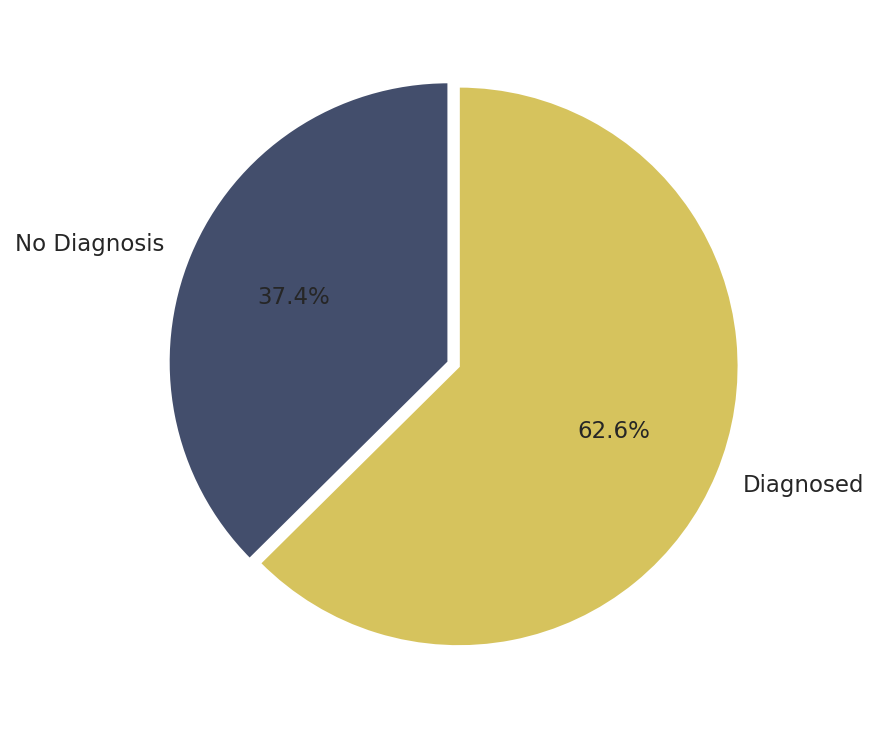

In [16]:
fig, ax = plt.subplots(figsize=(6, 6))

counts = mh_training["Diagnosed_mh"].value_counts().sort_index()
colors = plt.cm.cividis(np.linspace(0.25, 0.85, len(counts)))

ax.pie(
    counts,
    labels=[
        "No Diagnosis",
        "Diagnosed"
    ],
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    explode=(0.02, 0.02),
    wedgeprops={"edgecolor": "white", "linewidth": 1},
    textprops={"fontsize": 11}
)

print("Mental Health Diagnosis Distribution")

plt.tight_layout()

base_name = "class_distribution"
png_path = os.path.join(out_dir, f"{base_name}.png")
pdf_path = os.path.join(out_dir, f"{base_name}.pdf")

fig.savefig(png_path, bbox_inches="tight", pad_inches=0.02, dpi=600)
fig.savefig(pdf_path, bbox_inches="tight", pad_inches=0.02)

plt.show()
plt.close(fig)

We will use **Class Weights** by passing `class_weight='balanced'` to your $\text{LR-EN}$ model and the calculated `scale_pos_weight` to your $\text{XGBoost}$ model during your hyperparameter tuning.

In [17]:
features_to_scale = [
    'Age',
    'Company_size',
    'Ease_medical_leave',
    'Employer_importance_mental',
    'Coworker_reaction'
]

### **MODEL DEFINITION AND HYPERPARAMETER TUNING**

#### **Calculate Class Weights**

For XGBoost, we need the ratio of negative to positive samples `(scale_pos_weight)`. For the $\text{LR-EN}$ model, we'll use the `'balanced'` setting.

In [18]:
xgb_scale_pos_weight = (
    np.sum(y_train == 0) / np.sum(y_train == 1)
)

print(xgb_scale_pos_weight)

0.5980311730926989


#### **Bootstrap Confidence Interval Helper**

In [19]:
# ============================================================
# Bootstrap Confidence Interval Helper
# ============================================================

def bootstrap_metric(
    y_true,
    y_prob,
    metric_function,
    n_bootstraps=N_BOOTSTRAPS,
    confidence_level=CONFIDENCE_LEVEL,
    random_state=RANDOM_STATE,
):
    """
    Computes a bootstrap confidence interval for a performance metric.

    Parameters
    ----------
    y_true : array-like
        Ground-truth binary labels.

    y_prob : array-like
        Predicted probabilities for the positive class.

    metric_function : callable
        Metric accepting (y_true, y_prob), e.g.
        roc_auc_score or brier_score_loss.

    n_bootstraps : int
        Number of bootstrap resamples.

    confidence_level : float
        Confidence level (default = 0.95).

    random_state : int
        Random seed.

    Returns
    -------
    metric : float
        Metric computed on the original data.

    lower : float
        Lower confidence interval.

    upper : float
        Upper confidence interval.
    """

    rng = np.random.RandomState(random_state)
    scores = []

    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    n = len(y_true)

    for _ in range(n_bootstraps):

        indices = rng.choice(n, n, replace=True)

        # ROC-AUC requires both classes
        if len(np.unique(y_true[indices])) < 2:
            continue

        score = metric_function(
            y_true[indices],
            y_prob[indices]
        )

        scores.append(score)

    scores = np.sort(scores)

    alpha = (1 - confidence_level) / 2

    lower = np.percentile(scores, alpha * 100)
    upper = np.percentile(scores, (1 - alpha) * 100)

    metric = metric_function(y_true, y_prob)

    return metric, lower, upper

#### **LR-EN Tuning**

In [20]:
# ============================================================
# Elastic Net Logistic Regression
# ============================================================

# Scale selected features and retain all remaining predictors unchanged
lr_preprocessor = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), features_to_scale)
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
)

# Logistic Regression classifier
lr_en = LogisticRegression(
    penalty="elasticnet",
    solver="saga",
    random_state=RANDOM_STATE,
    max_iter=5000,
    tol=1e-4
)

# Complete modelling pipeline
lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", lr_preprocessor),
        ("classifier", lr_en)
    ]
)

# Hyperparameter search space
# C: inverse regularisation strength
# l1_ratio: 0 = L2, 1 = L1, intermediate values = Elastic Net
param_grid_lr = {
    "classifier__C": [0.001, 0.01, 0.1, 1.0, 10.0],
    "classifier__l1_ratio": [0.1, 0.5, 0.9],
    "classifier__class_weight": [None, "balanced"]
}

# Reproducible stratified cross-validation
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Grid search
grid_search_lr = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid_lr,
    scoring="roc_auc",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=0,
    refit=True,
    return_train_score=True,
    error_score="raise"
)

# Fit only on the historical training data
grid_search_lr.fit(X_train, y_train)

# Best fitted pipeline
best_lr_en = grid_search_lr.best_estimator_

print("Best Logistic Regression Parameters:")
print(grid_search_lr.best_params_)

print(
    f"Best Cross-Validated AUROC: "
    f"{grid_search_lr.best_score_:.4f}"
)

Best Logistic Regression Parameters:
{'classifier__C': 1.0, 'classifier__class_weight': None, 'classifier__l1_ratio': 0.9}
Best Cross-Validated AUROC: 0.7602


#### **XGBoost Tuning**

In [21]:
# ============================================================
# XGBoost Classifier
# ============================================================

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=xgb_scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist"
)

# Complete modelling pipeline
xgb_pipeline = Pipeline(
    steps=[
        ("classifier", xgb)
    ]
)

# Hyperparameter search space
param_grid_xgb = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [3, 5],
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__subsample": [0.8, 1.0],
    "classifier__colsample_bytree": [0.8, 1.0]
}

# Reproducible stratified cross-validation
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Grid search
grid_search_xgb = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid_xgb,
    scoring="roc_auc",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=0,
    refit=True,
    return_train_score=True,
    error_score="raise"
)

# Fit only on the historical training data
grid_search_xgb.fit(X_train, y_train)

# Best fitted pipeline
best_xgb = grid_search_xgb.best_estimator_

print("Best XGBoost Parameters:")
print(grid_search_xgb.best_params_)

print(
    f"Best Cross-Validated AUROC: "
    f"{grid_search_xgb.best_score_:.4f}"
)

Best XGBoost Parameters:
{'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}
Best Cross-Validated AUROC: 0.8077


#### **Random Forest Tuning**

In [22]:
# ============================================================
# Random Forest Classifier
# ============================================================

rf = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Complete modelling pipeline
rf_pipeline = Pipeline(
    steps=[
        ("classifier", rf)
    ]
)

# Hyperparameter search space
param_grid_rf = {
    "classifier__n_estimators": [200, 500],
    "classifier__max_depth": [10, 20, None],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2],
    "classifier__max_features": ["sqrt"],
    "classifier__class_weight": [None, "balanced"]
}

# Reproducible stratified cross-validation
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Grid search
grid_search_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    scoring="roc_auc",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=0,
    refit=True,
    return_train_score=True,
    error_score="raise"
)

# Fit only on the historical training data
grid_search_rf.fit(X_train, y_train)

# Best fitted pipeline
best_rf = grid_search_rf.best_estimator_

print("Best Random Forest Parameters:")
print(grid_search_rf.best_params_)

print(
    f"Best Cross-Validated AUROC: "
    f"{grid_search_rf.best_score_:.4f}"
)

Best Random Forest Parameters:
{'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 500}
Best Cross-Validated AUROC: 0.7857


In [23]:
print("\nModel Tuning Complete:")
print(f"LR-EN Best Params: {grid_search_lr.best_params_}")
print(f"XGBoost Best Params: {grid_search_xgb.best_params_}")
print(f"Random Forest Best Params: {grid_search_rf.best_params_}")


Model Tuning Complete:
LR-EN Best Params: {'classifier__C': 1.0, 'classifier__class_weight': None, 'classifier__l1_ratio': 0.9}
XGBoost Best Params: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}
Random Forest Best Params: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 500}


### **FINAL ANALYSIS: TEMPORAL DRIFT**

#### **Quantify Temporal Drift**

In [25]:
# ============================================================
# Quantitative Temporal Performance Drift
# ============================================================

models = {
    "LR-EN": best_lr_en,
    "XGBoost": best_xgb,
    "Random Forest": best_rf
}


def bootstrap_auc_difference(
    y_val,
    val_prob,
    y_test,
    test_prob,
    n_bootstraps=N_BOOTSTRAPS,
    confidence_level=CONFIDENCE_LEVEL,
    random_state=RANDOM_STATE
):
    """
    Estimates the bootstrap confidence interval for the difference
    between validation and test AUROC.

    Delta AUROC = Test AUROC - Validation AUROC

    Positive values indicate improved post-shift discrimination.
    Negative values indicate post-shift performance degradation.
    """

    y_val = np.asarray(y_val)
    val_prob = np.asarray(val_prob)
    y_test = np.asarray(y_test)
    test_prob = np.asarray(test_prob)

    rng = np.random.default_rng(random_state)
    bootstrap_differences = []

    for _ in range(n_bootstraps):

        val_indices = rng.choice(
            len(y_val),
            size=len(y_val),
            replace=True
        )

        test_indices = rng.choice(
            len(y_test),
            size=len(y_test),
            replace=True
        )

        # AUROC cannot be calculated when a resample has one class
        if (
            np.unique(y_val[val_indices]).size < 2
            or np.unique(y_test[test_indices]).size < 2
        ):
            continue

        val_auc_boot = roc_auc_score(
            y_val[val_indices],
            val_prob[val_indices]
        )

        test_auc_boot = roc_auc_score(
            y_test[test_indices],
            test_prob[test_indices]
        )

        bootstrap_differences.append(
            test_auc_boot - val_auc_boot
        )

    if not bootstrap_differences:
        raise ValueError(
            "No valid bootstrap samples contained both outcome classes."
        )

    alpha = (1 - confidence_level) / 2

    lower = np.percentile(
        bootstrap_differences,
        100 * alpha
    )

    upper = np.percentile(
        bootstrap_differences,
        100 * (1 - alpha)
    )

    return lower, upper


temporal_results = []

for model_name, model in models.items():

    # Predicted probabilities
    val_prob = model.predict_proba(X_val)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]

    # Validation AUROC and 95% CI
    val_auc, val_auc_lower, val_auc_upper = bootstrap_metric(
        y_true=y_val,
        y_prob=val_prob,
        metric_function=roc_auc_score
    )

    # Test AUROC and 95% CI
    test_auc, test_auc_lower, test_auc_upper = bootstrap_metric(
        y_true=y_test,
        y_prob=test_prob,
        metric_function=roc_auc_score
    )

    # Change from validation to test
    auc_change = test_auc - val_auc

    change_lower, change_upper = bootstrap_auc_difference(
        y_val=y_val,
        val_prob=val_prob,
        y_test=y_test,
        test_prob=test_prob
    )

    # Interpret the direction and statistical evidence
    if change_lower > 0:
        interpretation = "Significant improvement"
    elif change_upper < 0:
        interpretation = "Significant degradation"
    else:
        interpretation = "No clear change"

    temporal_results.append({
        "Model": model_name,
        "Validation AUROC": val_auc,
        "Validation 95% CI Lower": val_auc_lower,
        "Validation 95% CI Upper": val_auc_upper,
        "Test AUROC": test_auc,
        "Test 95% CI Lower": test_auc_lower,
        "Test 95% CI Upper": test_auc_upper,
        "Δ AUROC (Test − Validation)": auc_change,
        "Δ AUROC 95% CI Lower": change_lower,
        "Δ AUROC 95% CI Upper": change_upper,
        "Interpretation": interpretation
    })


temporal_results_df = pd.DataFrame(temporal_results)

display(
    temporal_results_df.round(4)
)

,Model,Validation AUROC,Validation 95% CI Lower,Validation 95% CI Upper,Test AUROC,Test 95% CI Lower,Test 95% CI Upper,Δ AUROC (Test − Validation),Δ AUROC 95% CI Lower,Δ AUROC 95% CI Upper,Interpretation
0,LR-EN,0.6551,0.4207,1.0,0.8067,0.6631,0.9202,0.1516,-0.2044,0.4207,No clear change
1,XGBoost,0.6620,0.3724,1.0,0.8126,0.6846,0.9060,0.1506,-0.2279,0.4674,No clear change
2,Random Forest,0.6111,0.2621,1.0,0.7741,0.5963,0.9173,0.1630,-0.2738,0.5357,No clear change


This version defines:

`ΔAUROC=Test AUROC−Validation AUROC`

Therefore:

* negative values indicate post-shift degradation;
* positive values indicate post-shift improvement;
* a confidence interval containing zero indicates insufficient evidence of a clear change.

This is preferable to always labelling the difference as “degradation,” particularly because the reviewer indicated that AUROC increased after the shift.

#### **Transparent Risk Factor Identification**

Also, using LR-EN alone is defensible here because odds ratios are native to Logistic Regression. Random Forest, XGBoost, and SVM do not produce directly interpretable coefficients or odds ratios. Their predictors should instead be examined using a model-agnostic or model-specific explanation method such as SHAP.

In [26]:
# ============================================================
# Transparent Risk Factor Identification using LR-EN
# ============================================================

# Extract the fitted preprocessing and classification stages
lr_preprocessor = best_lr_en.named_steps["preprocessor"]
lr_classifier = best_lr_en.named_steps["classifier"]

# Retrieve feature names in the exact order used by the classifier
feature_names = lr_preprocessor.get_feature_names_out()

# Extract fitted LR-EN coefficients
coefficients = lr_classifier.coef_.ravel()

# Validate alignment between transformed features and coefficients
if len(feature_names) != len(coefficients):
    raise ValueError(
        "The number of transformed feature names does not match "
        "the number of Logistic Regression coefficients."
    )

# Convert coefficients to odds ratios
odds_ratios = np.exp(coefficients)

# Assemble results
lr_results = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Odds Ratio": odds_ratios
})

# Classify coefficient direction
lr_results["Association"] = np.select(
    [
        lr_results["Coefficient"] > 0,
        lr_results["Coefficient"] < 0
    ],
    [
        "Higher odds",
        "Lower odds"
    ],
    default="No association"
)

# Rank positive and negative associations separately
top_higher_odds = (
    lr_results[lr_results["Coefficient"] > 0]
    .sort_values("Coefficient", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top_lower_odds = (
    lr_results[lr_results["Coefficient"] < 0]
    .sort_values("Coefficient", ascending=True)
    .head(10)
    .reset_index(drop=True)
)

print("Top 10 Predictors Associated with Higher Odds of Diagnosis:")
print(
    top_higher_odds[
        ["Feature", "Coefficient", "Odds Ratio", "Association"]
    ].to_markdown(index=False, floatfmt=".3f")
)

print("\nTop 10 Predictors Associated with Lower Odds of Diagnosis:")
print(
    top_lower_odds[
        ["Feature", "Coefficient", "Odds Ratio", "Association"]
    ].to_markdown(index=False, floatfmt=".3f")
)

Top 10 Predictors Associated with Higher Odds of Diagnosis:
| Feature                                      |   Coefficient |   Odds Ratio | Association   |
|:---------------------------------------------|--------------:|-------------:|:--------------|
| Family_history_Yes                           |         1.603 |        4.968 | Higher odds   |
| Anonymity_protected_Yes                      |         0.687 |        1.987 | Higher odds   |
| Observed_unsupportive_Yes                    |         0.553 |        1.739 | Higher odds   |
| Gender_Other                                 |         0.457 |        1.580 | Higher odds   |
| Comfort_coworkers_Yes                        |         0.414 |        1.513 | Higher odds   |
| Prev_emp_benefits_Yes, they all did          |         0.383 |        1.467 | Higher odds   |
| Know_mh_options_Yes                          |         0.364 |        1.439 | Higher odds   |
| Prev_options_Yes, I was aware of all of them |         0.293 |        1.34

In [27]:
# ============================================================
# Population Stability Index (PSI)
# Pre-shift validation cohort vs post-shift test cohort
# ============================================================

def calculate_psi(
    expected,
    actual,
    bins=10,
    categorical=False,
    epsilon=1e-6
):
    """
    Calculate the Population Stability Index between an expected
    distribution and an actual distribution.

    Parameters
    ----------
    expected : array-like
        Reference or pre-shift observations.

    actual : array-like
        Comparison or post-shift observations.

    bins : int, default=10
        Number of quantile-based bins for continuous variables.

    categorical : bool, default=False
        Whether the feature should be treated as categorical.

    epsilon : float, default=1e-6
        Small value used to avoid division by zero and log(0).

    Returns
    -------
    float
        Population Stability Index.
    """

    expected = pd.Series(expected).dropna()
    actual = pd.Series(actual).dropna()

    if expected.empty or actual.empty:
        return np.nan

    # --------------------------------------------------------
    # Categorical or low-cardinality feature
    # --------------------------------------------------------
    if categorical:
        categories = sorted(
            set(expected.unique()).union(set(actual.unique())),
            key=str
        )

        expected_dist = (
            expected.value_counts(normalize=True)
            .reindex(categories, fill_value=0.0)
        )

        actual_dist = (
            actual.value_counts(normalize=True)
            .reindex(categories, fill_value=0.0)
        )

    # --------------------------------------------------------
    # Continuous or ordinal numeric feature
    # --------------------------------------------------------
    else:
        quantiles = np.linspace(0, 1, bins + 1)

        breakpoints = np.unique(
            expected.quantile(quantiles).to_numpy()
        )

        # Fall back to category-based PSI when quantile binning
        # cannot create at least two distinct intervals
        if len(breakpoints) < 3:
            return calculate_psi(
                expected=expected,
                actual=actual,
                categorical=True,
                epsilon=epsilon
            )

        # Include actual observations beyond the expected range
        breakpoints[0] = -np.inf
        breakpoints[-1] = np.inf

        expected_bins = pd.cut(
            expected,
            bins=breakpoints,
            include_lowest=True,
            duplicates="drop"
        )

        actual_bins = pd.cut(
            actual,
            bins=breakpoints,
            include_lowest=True,
            duplicates="drop"
        )

        bin_categories = expected_bins.cat.categories

        expected_dist = (
            expected_bins.value_counts(normalize=True, sort=False)
            .reindex(bin_categories, fill_value=0.0)
        )

        actual_dist = (
            actual_bins.value_counts(normalize=True, sort=False)
            .reindex(bin_categories, fill_value=0.0)
        )

    # Prevent undefined logarithms
    expected_dist = expected_dist.clip(lower=epsilon)
    actual_dist = actual_dist.clip(lower=epsilon)

    # Renormalise after applying epsilon
    expected_dist = expected_dist / expected_dist.sum()
    actual_dist = actual_dist / actual_dist.sum()

    psi_components = (
        (actual_dist - expected_dist)
        * np.log(actual_dist / expected_dist)
    )

    return float(psi_components.sum())

**Bootstrap confidence intervals for PSI**

The validation and test cohorts are independent temporal samples, so they should be resampled independently.

In [28]:
# ============================================================
# Bootstrap Confidence Interval for PSI
# ============================================================

def bootstrap_psi(
    expected,
    actual,
    bins=10,
    categorical=False,
    n_bootstraps=N_BOOTSTRAPS,
    confidence_level=CONFIDENCE_LEVEL,
    random_state=RANDOM_STATE
):
    """
    Estimate a percentile bootstrap confidence interval for PSI.

    The interval represents sampling uncertainty around the estimated
    PSI. It should not be interpreted as a formal hypothesis test for
    the presence or absence of dataset shift.
    """

    expected = pd.Series(expected).dropna().reset_index(drop=True)
    actual = pd.Series(actual).dropna().reset_index(drop=True)

    if expected.empty or actual.empty:
        return np.nan, np.nan, np.nan, 0

    point_estimate = calculate_psi(
        expected=expected,
        actual=actual,
        bins=bins,
        categorical=categorical
    )

    rng = np.random.default_rng(random_state)
    bootstrap_scores = []

    for _ in range(n_bootstraps):
        expected_indices = rng.integers(
            low=0,
            high=len(expected),
            size=len(expected)
        )

        actual_indices = rng.integers(
            low=0,
            high=len(actual),
            size=len(actual)
        )

        expected_sample = expected.iloc[expected_indices]
        actual_sample = actual.iloc[actual_indices]

        score = calculate_psi(
            expected=expected_sample,
            actual=actual_sample,
            bins=bins,
            categorical=categorical
        )

        if np.isfinite(score):
            bootstrap_scores.append(score)

    if not bootstrap_scores:
        return point_estimate, np.nan, np.nan, 0

    alpha = (1 - confidence_level) / 2

    lower = np.percentile(
        bootstrap_scores,
        100 * alpha
    )

    upper = np.percentile(
        bootstrap_scores,
        100 * (1 - alpha)
    )

    return (
        point_estimate,
        lower,
        upper,
        len(bootstrap_scores)
    )

In [29]:
# ============================================================
# Binary Features for PSI
# ============================================================

# Features treated as binary distributions rather than continuous variables
binary_features = [
    column
    for column in X_val.columns
    if set(X_val[column].dropna().unique()).issubset({0, 1, True, False})
]

print(f"{len(binary_features)} binary features detected.\n")

print(binary_features)

27 binary features detected.

['Self_employed', 'Employer_tech', 'Mh_benefits_No', 'Mh_benefits_Not Eligible', 'Mh_benefits_Yes', 'Know_mh_options_Yes', 'Employer_discussed_mh_Yes', 'Mh_resources_Yes', 'Anonymity_protected_Yes', 'Prev_emp_benefits_Some did', 'Prev_emp_benefits_Yes, they all did', 'Prev_options_No, I only became aware later', 'Prev_options_Yes, I was aware of all of them', 'Prev_discussed_mh_Some did', 'Prev_discussed_mh_Yes, they all did', 'Prev_resources_Some did', 'Prev_resources_Yes, they all did', 'Prev_anonymity_Sometimes', 'Prev_anonymity_Yes, always', 'Comfort_coworkers_Yes', 'Comfort_supervisor_Yes', 'Willing_physical_Yes', 'Willing_interview_Yes', 'Observed_unsupportive_Yes', 'Family_history_Yes', 'Gender_Male', 'Gender_Other']


**Calculate PSI and 95% confidence intervals**

In [36]:
# ============================================================
# Feature-level PSI: Validation vs Test
# ============================================================

psi_results = []

for feature_index, feature in enumerate(X_val.columns):

    is_binary = feature in binary_features

    psi, ci_lower, ci_upper, valid_bootstraps = bootstrap_psi(
        expected=X_val[feature],
        actual=X_test[feature],
        bins=10,
        categorical=is_binary,
        n_bootstraps=N_BOOTSTRAPS,
        confidence_level=CONFIDENCE_LEVEL,
        random_state=RANDOM_STATE + feature_index
    )

    psi_results.append({
        "Feature": feature,
        "PSI": psi,
        "95% CI Lower": ci_lower,
        "95% CI Upper": ci_upper,
        "Valid Bootstraps": valid_bootstraps
    })


# Create and classify the PSI results
psi_df = pd.DataFrame(psi_results)

psi_df["Shift Magnitude"] = pd.cut(
    psi_df["PSI"],
    bins=[-np.inf, 0.10, 0.25, np.inf],
    labels=[
        "Limited shift",
        "Moderate shift",
        "Substantial shift"
    ],
    right=False
)

# Sort by greatest observed shift
psi_df = (
    psi_df
    .sort_values("PSI", ascending=False)
    .reset_index(drop=True)
)

print(
    "Top 20 features with the greatest temporal "
    "distribution shift:"
)

display(
    psi_df.head(20).style.format({
        "PSI": "{:.4f}",
        "95% CI Lower": "{:.4f}",
        "95% CI Upper": "{:.4f}",
        "Valid Bootstraps": "{:.0f}"
    })
)

Top 20 features with the greatest temporal distribution shift:


,Feature,PSI,95% CI Lower,95% CI Upper,Valid Bootstraps,Shift Magnitude
0,Ease_medical_leave,0.8166,0.4926,1.3629,1000,Substantial shift
1,Mh_resources_Yes,0.5747,0.3076,0.9553,1000,Substantial shift
2,Employer_discussed_mh_Yes,0.4489,0.1949,0.7986,1000,Substantial shift
3,Age,0.2338,0.1190,1.0025,1000,Moderate shift
4,Coworker_reaction,0.1699,0.0699,0.4861,1000,Moderate shift
5,Employer_importance_mental,0.1225,0.0536,0.4925,1000,Moderate shift
6,Company_size,0.0808,0.0161,0.3378,1000,Limited shift
7,Anonymity_protected_Yes,0.0760,0.0018,0.9443,1000,Limited shift
8,Self_employed,0.0744,0.0037,0.2565,1000,Limited shift
9,"Prev_resources_Yes, they all did",0.0625,0.0012,0.2809,1000,Limited shift


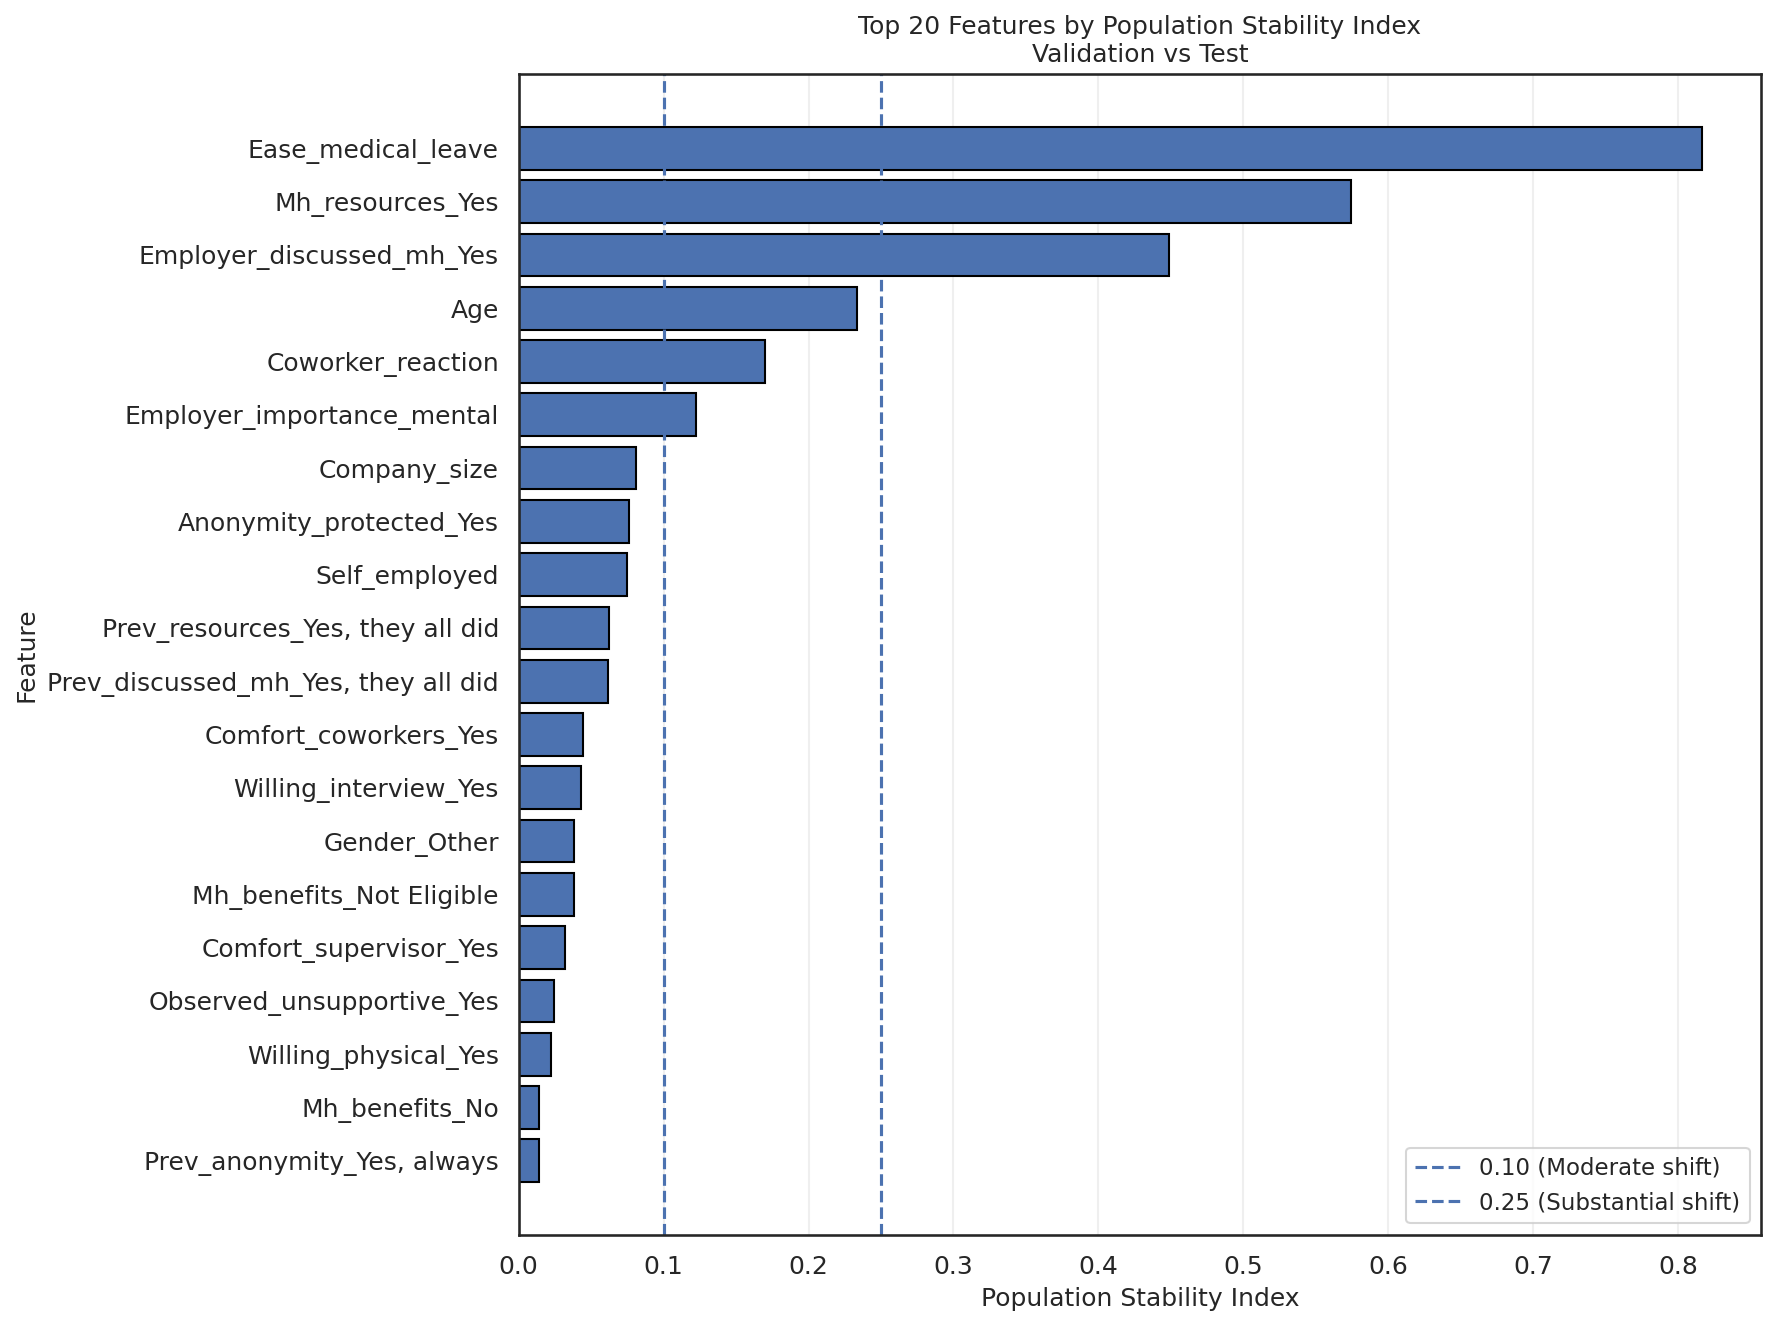

In [35]:
# ============================================================
# Top 20 Features by Population Stability Index
# ============================================================

top_psi = (
    psi_df
    .sort_values("PSI", ascending=False)
    .head(20)
    .sort_values("PSI", ascending=True)
)

fig, ax = plt.subplots(figsize=(12, 9))

ax.barh(
    top_psi["Feature"],
    top_psi["PSI"],
    height=0.8,
    edgecolor="black",
    linewidth=1.0
)

ax.axvline(
    0.10,
    linestyle="--",
    linewidth=1.5,
    label="0.10 (Moderate shift)"
)

ax.axvline(
    0.25,
    linestyle="--",
    linewidth=1.5,
    label="0.25 (Substantial shift)"
)

ax.set_xlabel("Population Stability Index")
ax.set_ylabel("Feature")
print("Top 20 Features by Population Stability Index Validation vs Test")

ax.legend()
ax.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()

base_name = "population_stability_index"
png_path = os.path.join(out_dir, f"{base_name}.png")
pdf_path = os.path.join(out_dir, f"{base_name}.pdf")

plt.savefig(
    png_path,
    bbox_inches="tight",
    pad_inches=0.02,
    dpi=600
)

plt.savefig(
    pdf_path,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()
plt.close(fig)

#### **Decision Threshold Stability**

In [37]:
# ============================================================
# Decision Threshold Stability under Temporal Dataset Shift
# ============================================================

def evaluate_thresholds(
    y_true,
    y_proba,
    thresholds=None
):
    """
    Evaluate classification performance across decision thresholds.

    Parameters
    ----------
    y_true : array-like
        True binary outcome labels.

    y_proba : array-like
        Predicted probabilities for the positive class.

    thresholds : array-like, optional
        Decision thresholds to evaluate. Defaults to 0.00-1.00
        in increments of 0.01.

    Returns
    -------
    pd.DataFrame
        Performance metrics calculated at each threshold.
    """

    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)

    if thresholds is None:
        thresholds = np.arange(0.00, 1.01, 0.01)

    records = []

    for threshold in thresholds:

        y_pred = (y_proba >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1]
        ).ravel()

        sensitivity = (
            tp / (tp + fn)
            if (tp + fn) > 0
            else np.nan
        )

        specificity = (
            tn / (tn + fp)
            if (tn + fp) > 0
            else np.nan
        )

        precision = precision_score(
            y_true,
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_true,
            y_pred,
            zero_division=0
        )

        balanced_accuracy = balanced_accuracy_score(
            y_true,
            y_pred
        )

        # MCC is undefined when predictions contain only one class
        if np.unique(y_pred).size < 2:
            mcc = np.nan
        else:
            mcc = matthews_corrcoef(
                y_true,
                y_pred
            )

        records.append({
            "Threshold": threshold,
            "Sensitivity": sensitivity,
            "Specificity": specificity,
            "Precision": precision,
            "F1": f1,
            "MCC": mcc,
            "Balanced Accuracy": balanced_accuracy,
            "True Positives": tp,
            "False Positives": fp,
            "True Negatives": tn,
            "False Negatives": fn
        })

    return pd.DataFrame(records)

In [38]:
# ============================================================
# Threshold-Based Temporal Robustness Comparison
# ============================================================

models = {
    "LR-EN": best_lr_en,
    "XGBoost": best_xgb,
    "Random Forest": best_rf,
}

threshold_grid = np.arange(0.00, 1.01, 0.01)

# Select thresholds using validation data only
threshold_selection_metric = "MCC"

threshold_metrics = [
    "Sensitivity",
    "Specificity",
    "Precision",
    "F1",
    "MCC",
    "Balanced Accuracy"
]

model_threshold_results = {}
threshold_comparison_records = []

In [39]:
# ============================================================
# Evaluate Every Model across the Common Threshold Grid
# ============================================================

for model_name, model in models.items():

    # Predicted probabilities
    y_val_proba = model.predict_proba(X_val)[:, 1]
    y_test_proba = model.predict_proba(X_test)[:, 1]

    # Threshold-dependent performance
    threshold_val = evaluate_thresholds(
        y_true=y_val,
        y_proba=y_val_proba,
        thresholds=threshold_grid
    )

    threshold_test = evaluate_thresholds(
        y_true=y_test,
        y_proba=y_test_proba,
        thresholds=threshold_grid
    )

    # Remove thresholds at which the selection metric is undefined
    valid_rows = threshold_val.dropna(
        subset=[threshold_selection_metric]
    )

    if valid_rows.empty:
        raise ValueError(
            f"No valid {threshold_selection_metric} values "
            f"were available for {model_name}."
        )

    # Select threshold exclusively from validation data
    optimal_index = valid_rows[
        threshold_selection_metric
    ].idxmax()

    optimal_validation_row = threshold_val.loc[
        optimal_index
    ]

    optimal_threshold = float(
        optimal_validation_row["Threshold"]
    )

    # Transfer the validation-selected threshold unchanged
    # to the temporally later test cohort
    optimal_test_row = threshold_test.loc[
        np.isclose(
            threshold_test["Threshold"],
            optimal_threshold
        )
    ].iloc[0]

    # Store the complete curves for later plotting
    model_threshold_results[model_name] = {
        "Model": model,
        "Validation Probabilities": y_val_proba,
        "Test Probabilities": y_test_proba,
        "Validation Curve": threshold_val,
        "Test Curve": threshold_test,
        "Selected Threshold": optimal_threshold
    }

    comparison_record = {
        "Model": model_name,
        "Selected Threshold": optimal_threshold
    }

    # Store validation, test, and temporal change for each metric
    for metric in threshold_metrics:

        validation_value = optimal_validation_row[metric]
        test_value = optimal_test_row[metric]

        comparison_record[
            f"Validation {metric}"
        ] = validation_value

        comparison_record[
            f"Test {metric}"
        ] = test_value

        comparison_record[
            f"Δ {metric} (Test − Validation)"
        ] = test_value - validation_value

    threshold_comparison_records.append(
        comparison_record
    )

In [40]:
# ============================================================
# Model Comparison at Validation-Selected Thresholds
# ============================================================

threshold_comparison_df = pd.DataFrame(
    threshold_comparison_records
)

# Absolute temporal changes are useful for measuring stability
for metric in threshold_metrics:
    threshold_comparison_df[
        f"|Δ {metric}|"
    ] = threshold_comparison_df[
        f"Δ {metric} (Test − Validation)"
    ].abs()

# Example ordering:
# 1. strongest test MCC
# 2. smallest absolute MCC change
# 3. strongest test balanced accuracy
threshold_comparison_df = (
    threshold_comparison_df
    .sort_values(
        by=[
            "Test MCC",
            "|Δ MCC|",
            "Test Balanced Accuracy"
        ],
        ascending=[
            False,
            True,
            False
        ]
    )
    .reset_index(drop=True)
)

display(
    threshold_comparison_df.style.format({
        column: "{:.4f}"
        for column in threshold_comparison_df.columns
        if column != "Model"
    })
)

,Model,Selected Threshold,Validation Sensitivity,Test Sensitivity,Δ Sensitivity (Test − Validation),Validation Specificity,Test Specificity,Δ Specificity (Test − Validation),Validation Precision,Test Precision,Δ Precision (Test − Validation),Validation F1,Test F1,Δ F1 (Test − Validation),Validation MCC,Test MCC,Δ MCC (Test − Validation),Validation Balanced Accuracy,Test Balanced Accuracy,Δ Balanced Accuracy (Test − Validation),|Δ Sensitivity|,|Δ Specificity|,|Δ Precision|,|Δ F1|,|Δ MCC|,|Δ Balanced Accuracy|
0,LR-EN,0.2200,1.0000,0.9926,-0.0074,0.3333,0.0000,-0.3333,0.9863,0.9306,-0.0557,0.9931,0.9606,-0.0325,0.5734,-0.0227,-0.5961,0.6667,0.4963,-0.1704,0.0074,0.3333,0.0557,0.0325,0.5961,0.1704
1,XGBoost,0.2700,1.0000,0.9704,-0.0296,0.3333,0.0000,-0.3333,0.9863,0.9291,-0.0572,0.9931,0.9493,-0.0438,0.5734,-0.0458,-0.6192,0.6667,0.4852,-0.1815,0.0296,0.3333,0.0572,0.0438,0.6192,0.1815
2,Random Forest,0.2700,1.0000,1.0000,0.0000,0.3333,0.0000,-0.3333,0.9863,0.9310,-0.0553,0.9931,0.9643,-0.0288,0.5734,nan,nan,0.6667,0.5000,-0.1667,0.0000,0.3333,0.0553,0.0288,nan,0.1667


In [41]:
# ============================================================
# Compact Threshold Robustness Summary
# ============================================================

threshold_summary_columns = [
    "Model",
    "Selected Threshold",

    "Validation Sensitivity",
    "Test Sensitivity",
    "Δ Sensitivity (Test − Validation)",

    "Validation Specificity",
    "Test Specificity",
    "Δ Specificity (Test − Validation)",

    "Validation MCC",
    "Test MCC",
    "Δ MCC (Test − Validation)",

    "Validation Balanced Accuracy",
    "Test Balanced Accuracy",
    "Δ Balanced Accuracy (Test − Validation)"
]

threshold_summary_df = threshold_comparison_df[
    threshold_summary_columns
].copy()

display(
    threshold_summary_df.style.format({
        column: "{:.4f}"
        for column in threshold_summary_df.columns
        if column != "Model"
    })
)

,Model,Selected Threshold,Validation Sensitivity,Test Sensitivity,Δ Sensitivity (Test − Validation),Validation Specificity,Test Specificity,Δ Specificity (Test − Validation),Validation MCC,Test MCC,Δ MCC (Test − Validation),Validation Balanced Accuracy,Test Balanced Accuracy,Δ Balanced Accuracy (Test − Validation)
0,LR-EN,0.2200,1.0000,0.9926,-0.0074,0.3333,0.0000,-0.3333,0.5734,-0.0227,-0.5961,0.6667,0.4963,-0.1704
1,XGBoost,0.2700,1.0000,0.9704,-0.0296,0.3333,0.0000,-0.3333,0.5734,-0.0458,-0.6192,0.6667,0.4852,-0.1815
2,Random Forest,0.2700,1.0000,1.0000,0.0000,0.3333,0.0000,-0.3333,0.5734,nan,nan,0.6667,0.5000,-0.1667


In [42]:
# ============================================================
# Select the Deployment Model
# ============================================================

selected_model_row = (
    threshold_comparison_df
    .sort_values(
        by=[
            "Test MCC",
            "|Δ MCC|",
            "Test Balanced Accuracy",
            "|Δ Balanced Accuracy|"
        ],
        ascending=[
            False,
            True,
            False,
            True
        ]
    )
    .iloc[0]
)

selected_model_name = selected_model_row["Model"]
selected_model = models[selected_model_name]

selected_threshold = float(
    selected_model_row["Selected Threshold"]
)

print(f"Selected deployment model: {selected_model_name}")
print(f"Validation-selected threshold: {selected_threshold:.2f}")
print(f"Test MCC: {selected_model_row['Test MCC']:.4f}")
print(
    "MCC temporal change: "
    f"{selected_model_row['Δ MCC (Test − Validation)']:+.4f}"
)
print(
    "Test balanced accuracy: "
    f"{selected_model_row['Test Balanced Accuracy']:.4f}"
)

Selected deployment model: LR-EN
Validation-selected threshold: 0.22
Test MCC: -0.0227
MCC temporal change: -0.5961
Test balanced accuracy: 0.4963


In [43]:
# ============================================================
# Selected Model Threshold Curves
# ============================================================

selected_threshold_results = model_threshold_results[
    selected_model_name
]

threshold_val = selected_threshold_results[
    "Validation Curve"
]

threshold_test = selected_threshold_results[
    "Test Curve"
]

optimal_threshold = selected_threshold_results[
    "Selected Threshold"
]

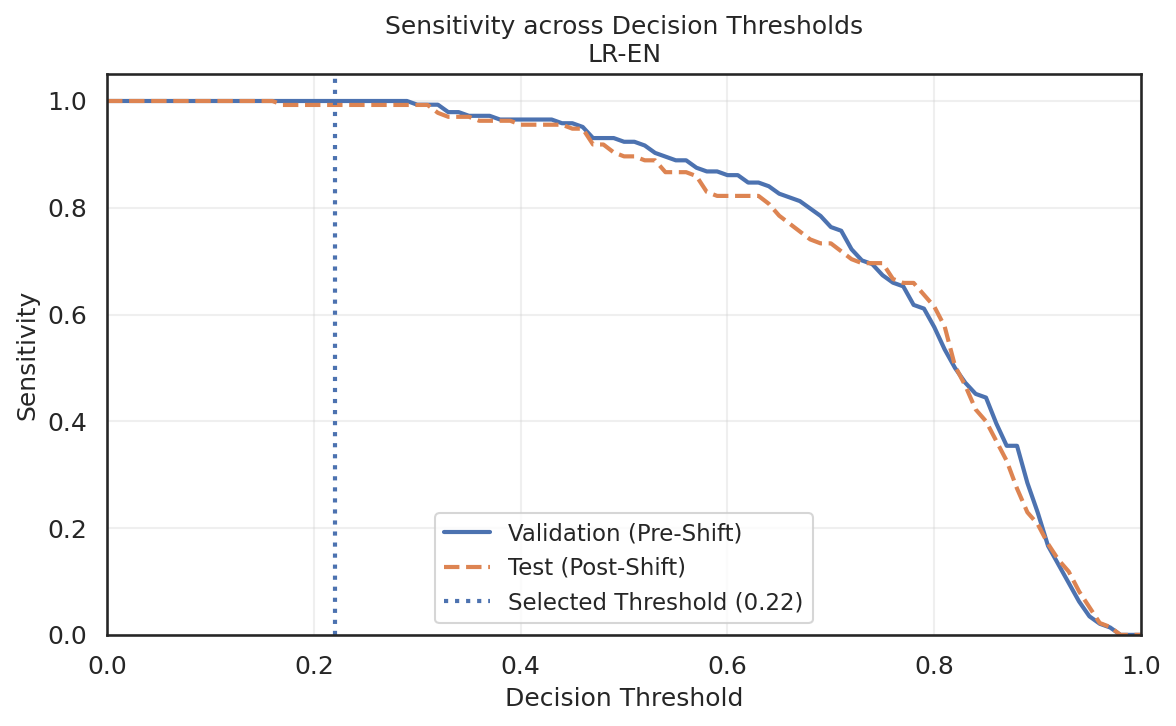

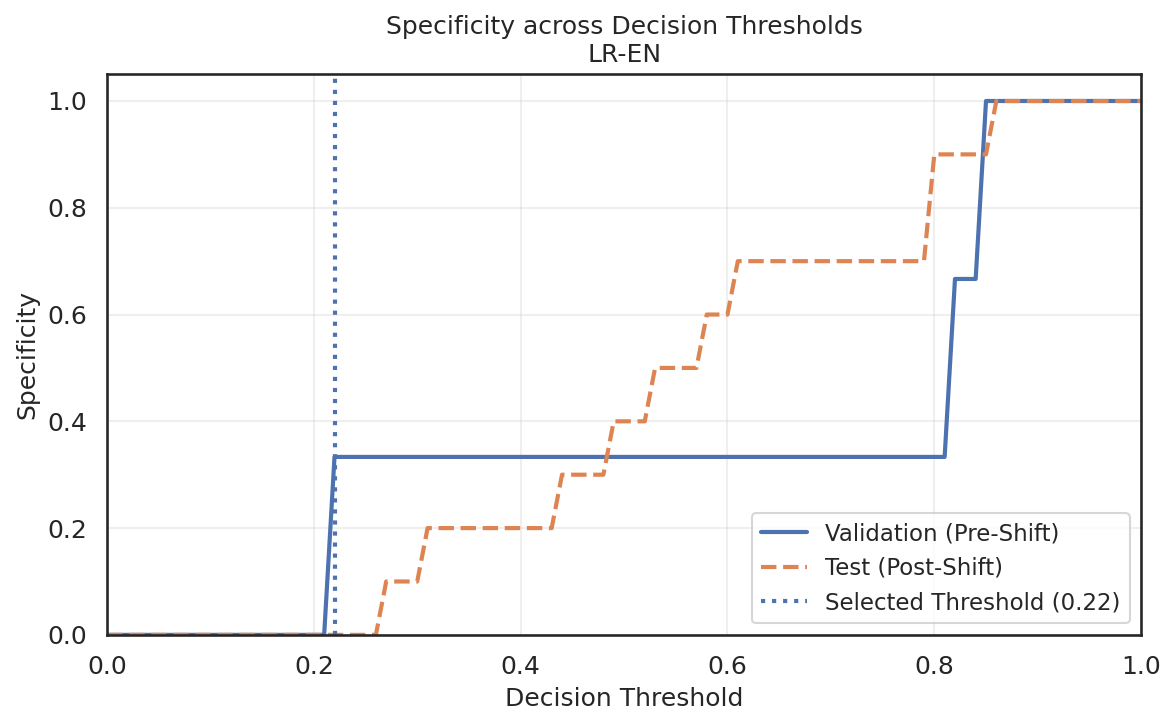

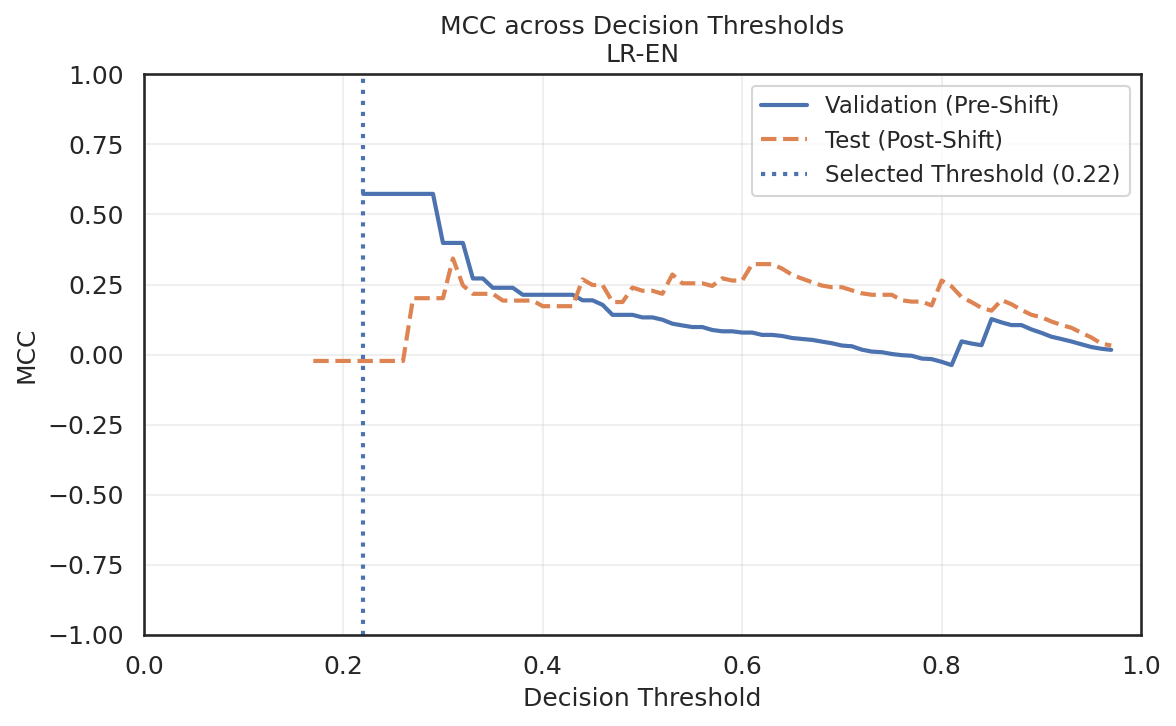

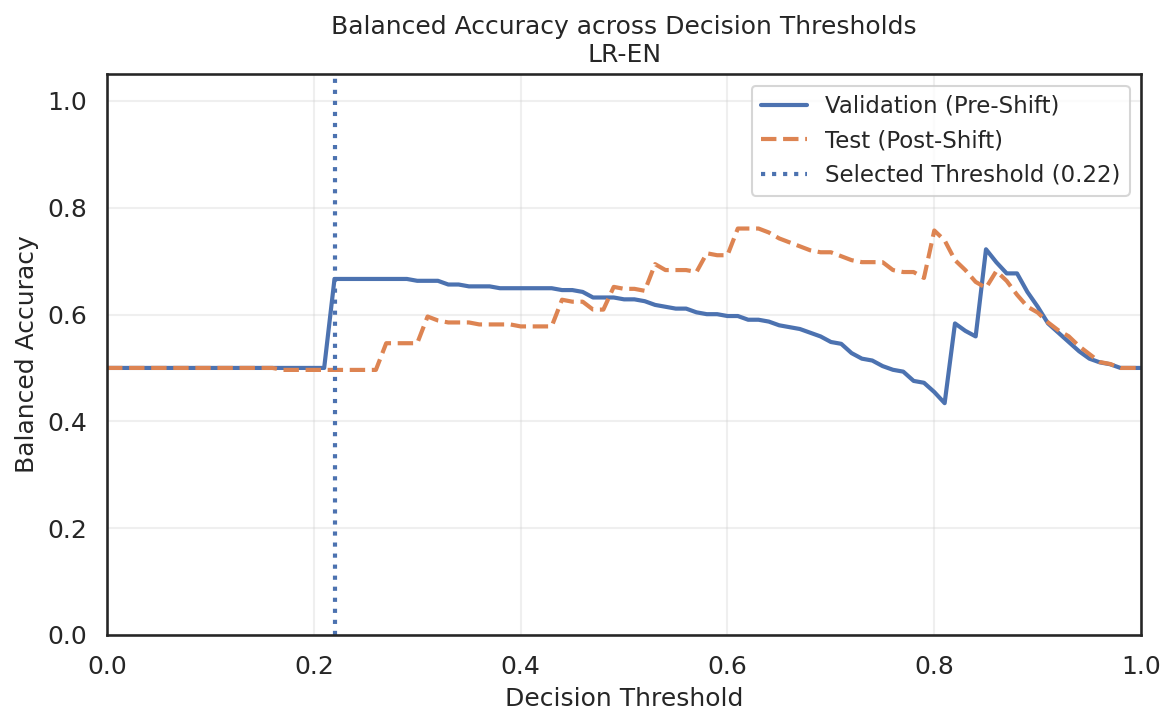

In [45]:
# ============================================================
# Threshold Stability Curves for the Selected Model
# ============================================================

metrics_to_plot = [
    "Sensitivity",
    "Specificity",
    "MCC",
    "Balanced Accuracy"
]

for metric in metrics_to_plot:

    fig, ax = plt.subplots(figsize=(8, 5))

    # Validation (Pre-shift)
    ax.plot(
        threshold_val["Threshold"],
        threshold_val[metric],
        linewidth=2,
        label="Validation (Pre-Shift)"
    )

    # Test (Post-shift)
    ax.plot(
        threshold_test["Threshold"],
        threshold_test[metric],
        linewidth=2,
        linestyle="--",
        label="Test (Post-Shift)"
    )

    # Selected threshold
    ax.axvline(
        optimal_threshold,
        linestyle=":",
        linewidth=2,
        label=f"Selected Threshold ({optimal_threshold:.2f})"
    )

    ax.set_xlabel("Decision Threshold")
    ax.set_ylabel(metric)

    ax.set_title(
        f"{metric} across Decision Thresholds\n"
        f"{selected_model_name}"
    )

    ax.set_xlim(0, 1)

    if metric == "MCC":
        ax.set_ylim(-1, 1)
    else:
        ax.set_ylim(0, 1.05)

    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()

    # Save figure
    safe_metric = (
        metric.lower()
        .replace(" ", "_")
    )

    base_name = f"threshold_stability_{safe_metric}"

    png_path = os.path.join(out_dir, f"{base_name}.png")
    pdf_path = os.path.join(out_dir, f"{base_name}.pdf")

    plt.savefig(
        png_path,
        dpi=600,
        bbox_inches="tight",
        pad_inches=0.02
    )

    plt.savefig(
        pdf_path,
        bbox_inches="tight",
        pad_inches=0.02
    )

    plt.show()
    plt.close(fig)

**Select the deployment threshold using validation data**

Because the class distribution is imbalanced, MCC is a defensible primary threshold-selection criterion. Balanced accuracy or F1 can be substituted if that better matches the paper's stated deployment objective.

In [46]:
# ============================================================
# Validation-Based Threshold Selection
# ============================================================

threshold_selection_metric = "MCC"

valid_threshold_rows = threshold_val.dropna(
    subset=[threshold_selection_metric]
)

optimal_row = valid_threshold_rows.loc[
    valid_threshold_rows[
        threshold_selection_metric
    ].idxmax()
]

optimal_threshold = float(
    optimal_row["Threshold"]
)

print(
    f"Selected model: {selected_model_name}"
)

print(
    f"Threshold-selection metric: "
    f"{threshold_selection_metric}"
)

print(
    f"Optimal validation threshold: "
    f"{optimal_threshold:.2f}"
)

print(
    f"Validation {threshold_selection_metric}: "
    f"{optimal_row[threshold_selection_metric]:.4f}"
)

Selected model: LR-EN
Threshold-selection metric: MCC
Optimal validation threshold: 0.22
Validation MCC: 0.5734


**Compare validation and test performance at the selected threshold**

In [47]:
# ============================================================
# Operating Performance at the Selected Threshold
# ============================================================

val_selected = threshold_val.loc[
    np.isclose(
        threshold_val["Threshold"],
        optimal_threshold
    )
].iloc[0]

test_selected = threshold_test.loc[
    np.isclose(
        threshold_test["Threshold"],
        optimal_threshold
    )
].iloc[0]

metrics_to_report = [
    "Sensitivity",
    "Specificity",
    "Precision",
    "F1",
    "MCC",
    "Balanced Accuracy"
]

selected_threshold_results = []

for metric in metrics_to_report:

    validation_value = val_selected[metric]
    test_value = test_selected[metric]

    selected_threshold_results.append({
        "Metric": metric,
        "Validation": validation_value,
        "Test": test_value,
        "Change (Test − Validation)": (
            test_value - validation_value
        )
    })

selected_threshold_results_df = pd.DataFrame(
    selected_threshold_results
)

print(
    f"Performance at validation-selected threshold "
    f"({optimal_threshold:.2f}):"
)

display(
    selected_threshold_results_df.style.format({
        "Validation": "{:.4f}",
        "Test": "{:.4f}",
        "Change (Test − Validation)": "{:+.4f}"
    })
)

Performance at validation-selected threshold (0.22):


,Metric,Validation,Test,Change (Test − Validation)
0,Sensitivity,1.0000,0.9926,-0.0074
1,Specificity,0.3333,0.0000,-0.3333
2,Precision,0.9863,0.9306,-0.0557
3,F1,0.9931,0.9606,-0.0325
4,MCC,0.5734,-0.0227,-0.5961
5,Balanced Accuracy,0.6667,0.4963,-0.1704


#### **PDP Drift – Shape Change in Feature–Outcome Relationship**

Partial Dependence Difference (PDP-Δ)

This answers:
> *Did the relationship between the feature and diagnosis change shape?*

For example, age may be linearly increasing risk before, but flat afterward.

In [52]:
# ============================================================
# PDP-Based Explanation Drift under Temporal Dataset Shift
# ============================================================

def create_pdp_grid(
    expected,
    actual,
    is_binary=False,
    grid_resolution=20,
    lower_quantile=0.05,
    upper_quantile=0.95
):
    """
    Create a common feature grid for validation and test PDP estimation.

    For binary features, the grid is [0, 1].

    For numeric or ordinal features, the grid is restricted to the
    overlapping central range of the validation and test distributions
    to reduce unsupported extrapolation.
    """

    expected = pd.Series(expected).dropna()
    actual = pd.Series(actual).dropna()

    if expected.empty or actual.empty:
        raise ValueError(
            "Both validation and test feature distributions "
            "must contain non-missing observations."
        )

    if is_binary:
        return np.array([0, 1], dtype=float)

    expected_lower = expected.quantile(lower_quantile)
    expected_upper = expected.quantile(upper_quantile)

    actual_lower = actual.quantile(lower_quantile)
    actual_upper = actual.quantile(upper_quantile)

    # Restrict the grid to the overlapping distributional range
    lower_bound = max(expected_lower, actual_lower)
    upper_bound = min(expected_upper, actual_upper)

    # Fall back to the full shared range when the central ranges
    # do not overlap sufficiently
    if lower_bound >= upper_bound:
        lower_bound = max(expected.min(), actual.min())
        upper_bound = min(expected.max(), actual.max())

    if lower_bound >= upper_bound:
        unique_values = np.unique(
            np.concatenate([
                expected.to_numpy(),
                actual.to_numpy()
            ])
        )

        return unique_values.astype(float)

    return np.linspace(
        lower_bound,
        upper_bound,
        grid_resolution
    )

**Pipeline-compatible PDP calculation**

This manually calculates partial dependence so that exactly the same grid is used for both temporal cohorts.

In [53]:
# ============================================================
# Manual Partial Dependence Calculation
# ============================================================

def calculate_pdp(
    model,
    X,
    feature_name,
    feature_grid
):
    """
    Calculate partial dependence probabilities for one feature.

    At each grid value, the selected feature is replaced for all
    observations while all remaining features retain their observed
    values. The mean predicted probability is then calculated.
    """

    if feature_name not in X.columns:
        raise ValueError(
            f"Feature '{feature_name}' was not found in X."
        )

    pdp_values = []

    for feature_value in feature_grid:

        X_modified = X.copy()
        X_modified[feature_name] = feature_value

        probabilities = model.predict_proba(
            X_modified
        )[:, 1]

        pdp_values.append(
            probabilities.mean()
        )

    return np.asarray(pdp_values)

**Bootstrap confidence intervals for each PDP curve**

The observations are resampled independently within the validation and test cohorts.

In [54]:
# ============================================================
# Bootstrap Confidence Intervals for PDP Curves
# ============================================================

def bootstrap_pdp_curve(
    model,
    X,
    feature_name,
    feature_grid,
    n_bootstraps=N_BOOTSTRAPS,
    confidence_level=CONFIDENCE_LEVEL,
    random_state=RANDOM_STATE
):
    """
    Estimate a PDP curve and percentile bootstrap confidence intervals.
    """

    X = X.reset_index(drop=True)

    if X.empty:
        raise ValueError("X must contain at least one observation.")

    point_estimate = calculate_pdp(
        model=model,
        X=X,
        feature_name=feature_name,
        feature_grid=feature_grid
    )

    rng = np.random.default_rng(random_state)
    bootstrap_curves = []

    for _ in range(n_bootstraps):

        sample_indices = rng.integers(
            low=0,
            high=len(X),
            size=len(X)
        )

        X_sample = X.iloc[sample_indices].reset_index(
            drop=True
        )

        bootstrap_curve = calculate_pdp(
            model=model,
            X=X_sample,
            feature_name=feature_name,
            feature_grid=feature_grid
        )

        bootstrap_curves.append(
            bootstrap_curve
        )

    bootstrap_curves = np.asarray(
        bootstrap_curves
    )

    alpha = (1 - confidence_level) / 2

    lower_ci = np.percentile(
        bootstrap_curves,
        100 * alpha,
        axis=0
    )

    upper_ci = np.percentile(
        bootstrap_curves,
        100 * (1 - alpha),
        axis=0
    )

    return point_estimate, lower_ci, upper_ci

**Bootstrap the PDP drift statistics**

This estimates uncertainty around the difference between the validation and test PDP curves.

In [55]:
# ============================================================
# Bootstrap PDP Drift Metrics
# ============================================================

def bootstrap_pdp_drift(
    model,
    X_expected,
    X_actual,
    feature_name,
    feature_grid,
    n_bootstraps=N_BOOTSTRAPS,
    confidence_level=CONFIDENCE_LEVEL,
    random_state=RANDOM_STATE
):
    """
    Calculate PDP explanation drift between validation and test cohorts.

    Drift metrics
    -------------
    Mean absolute difference:
        Average absolute distance between the two PDP curves.

    Maximum absolute difference:
        Largest absolute distance at any point on the feature grid.

    Signed mean difference:
        Average post-shift PDP minus pre-shift PDP.
    """

    X_expected = X_expected.reset_index(drop=True)
    X_actual = X_actual.reset_index(drop=True)

    expected_pdp = calculate_pdp(
        model=model,
        X=X_expected,
        feature_name=feature_name,
        feature_grid=feature_grid
    )

    actual_pdp = calculate_pdp(
        model=model,
        X=X_actual,
        feature_name=feature_name,
        feature_grid=feature_grid
    )

    difference = actual_pdp - expected_pdp

    point_estimates = {
        "PDP Mean Absolute Difference": np.mean(
            np.abs(difference)
        ),
        "PDP Maximum Absolute Difference": np.max(
            np.abs(difference)
        ),
        "PDP Signed Mean Difference": np.mean(
            difference
        )
    }

    rng = np.random.default_rng(random_state)

    bootstrap_mad = []
    bootstrap_max_difference = []
    bootstrap_signed_difference = []

    for _ in range(n_bootstraps):

        expected_indices = rng.integers(
            low=0,
            high=len(X_expected),
            size=len(X_expected)
        )

        actual_indices = rng.integers(
            low=0,
            high=len(X_actual),
            size=len(X_actual)
        )

        expected_sample = (
            X_expected
            .iloc[expected_indices]
            .reset_index(drop=True)
        )

        actual_sample = (
            X_actual
            .iloc[actual_indices]
            .reset_index(drop=True)
        )

        expected_bootstrap_pdp = calculate_pdp(
            model=model,
            X=expected_sample,
            feature_name=feature_name,
            feature_grid=feature_grid
        )

        actual_bootstrap_pdp = calculate_pdp(
            model=model,
            X=actual_sample,
            feature_name=feature_name,
            feature_grid=feature_grid
        )

        bootstrap_difference = (
            actual_bootstrap_pdp
            - expected_bootstrap_pdp
        )

        bootstrap_mad.append(
            np.mean(
                np.abs(bootstrap_difference)
            )
        )

        bootstrap_max_difference.append(
            np.max(
                np.abs(bootstrap_difference)
            )
        )

        bootstrap_signed_difference.append(
            np.mean(
                bootstrap_difference
            )
        )

    alpha = (1 - confidence_level) / 2

    def percentile_interval(values):
        return (
            np.percentile(values, 100 * alpha),
            np.percentile(values, 100 * (1 - alpha))
        )

    mad_lower, mad_upper = percentile_interval(
        bootstrap_mad
    )

    max_lower, max_upper = percentile_interval(
        bootstrap_max_difference
    )

    signed_lower, signed_upper = percentile_interval(
        bootstrap_signed_difference
    )

    return {
        **point_estimates,
        "MAD 95% CI Lower": mad_lower,
        "MAD 95% CI Upper": mad_upper,
        "Maximum Difference 95% CI Lower": max_lower,
        "Maximum Difference 95% CI Upper": max_upper,
        "Signed Difference 95% CI Lower": signed_lower,
        "Signed Difference 95% CI Upper": signed_upper
    }

**Run the explanation-drift analysis**


In [56]:
# ============================================================
# Selected Model and Features
# ============================================================

selected_model_name = selected_model_name
selected_model = best_lr_en

pdp_features = [
    "Age",
    "Employer_importance_mental"
]

pdp_drift_records = []

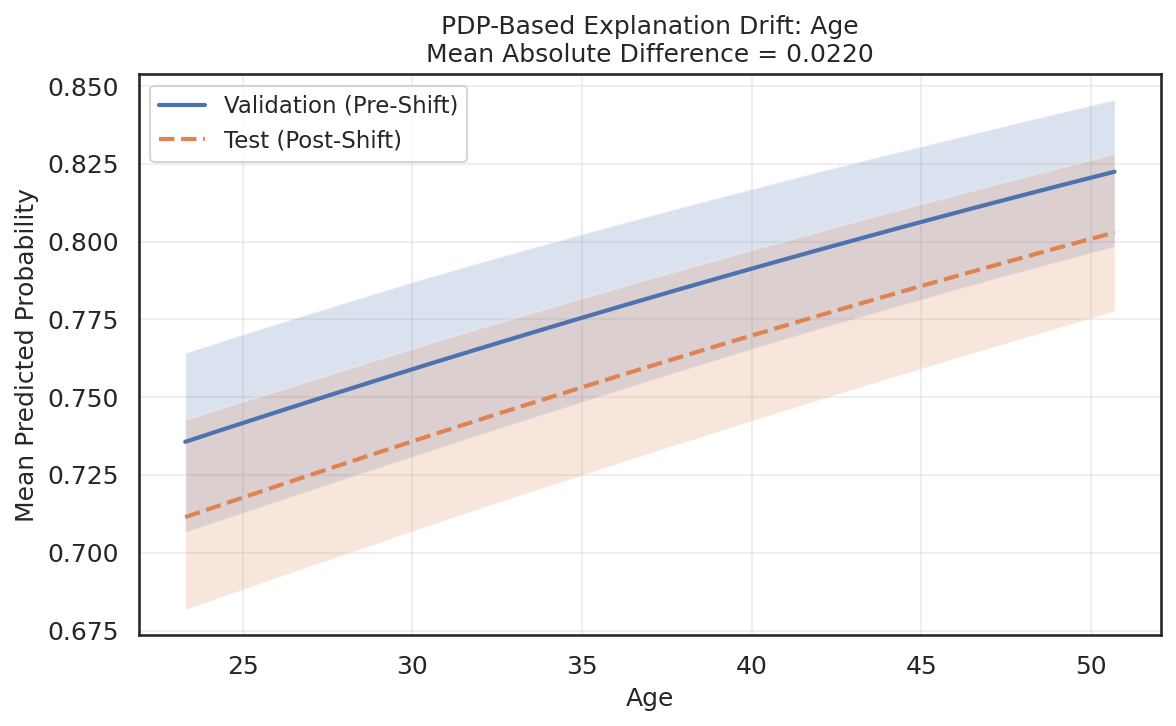

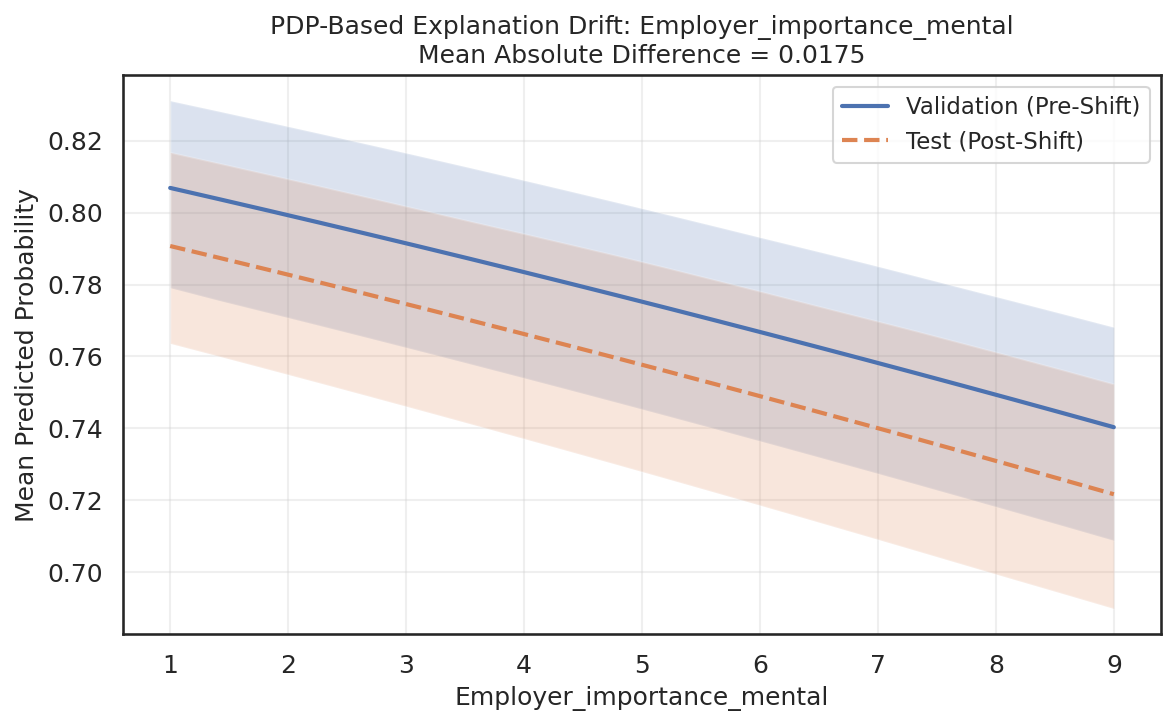

In [57]:
# ============================================================
# PDP Explanation-Drift Evaluation
# ============================================================

for feature_index, feature in enumerate(pdp_features):

    if feature not in X_val.columns:
        raise ValueError(
            f"Feature '{feature}' was not found in X_val."
        )

    if feature not in X_test.columns:
        raise ValueError(
            f"Feature '{feature}' was not found in X_test."
        )

    is_binary = feature in binary_features

    common_grid = create_pdp_grid(
        expected=X_val[feature],
        actual=X_test[feature],
        is_binary=is_binary,
        grid_resolution=20
    )

    # Validation PDP and confidence interval
    pdp_pre, pdp_pre_lower, pdp_pre_upper = (
        bootstrap_pdp_curve(
            model=selected_model,
            X=X_val,
            feature_name=feature,
            feature_grid=common_grid,
            n_bootstraps=N_BOOTSTRAPS,
            confidence_level=CONFIDENCE_LEVEL,
            random_state=RANDOM_STATE + feature_index
        )
    )

    # Test PDP and confidence interval
    pdp_post, pdp_post_lower, pdp_post_upper = (
        bootstrap_pdp_curve(
            model=selected_model,
            X=X_test,
            feature_name=feature,
            feature_grid=common_grid,
            n_bootstraps=N_BOOTSTRAPS,
            confidence_level=CONFIDENCE_LEVEL,
            random_state=(
                RANDOM_STATE
                + 1000
                + feature_index
            )
        )
    )

    drift_results = bootstrap_pdp_drift(
        model=selected_model,
        X_expected=X_val,
        X_actual=X_test,
        feature_name=feature,
        feature_grid=common_grid,
        n_bootstraps=N_BOOTSTRAPS,
        confidence_level=CONFIDENCE_LEVEL,
        random_state=(
            RANDOM_STATE
            + 2000
            + feature_index
        )
    )

    pdp_drift_records.append({
        "Feature": feature,
        "Feature Type": (
            "Binary"
            if is_binary
            else "Numeric/Ordinal"
        ),
        **drift_results
    })

    # --------------------------------------------------------
    # Plot validation and test PDP curves
    # --------------------------------------------------------

    plt.figure(figsize=(8, 5))

    plt.plot(
        common_grid,
        pdp_pre,
        label="Validation (Pre-Shift)",
        linewidth=2
    )

    plt.fill_between(
        common_grid,
        pdp_pre_lower,
        pdp_pre_upper,
        alpha=0.20
    )

    plt.plot(
        common_grid,
        pdp_post,
        label="Test (Post-Shift)",
        linewidth=2,
        linestyle="--"
    )

    plt.fill_between(
        common_grid,
        pdp_post_lower,
        pdp_post_upper,
        alpha=0.20
    )

    plt.xlabel(feature)
    plt.ylabel("Mean Predicted Probability")

    plt.title(
        f"PDP-Based Explanation Drift: {feature}\n"
        f"Mean Absolute Difference = "
        f"{drift_results['PDP Mean Absolute Difference']:.4f}"
    )

    if is_binary:
        plt.xticks(
            [0, 1],
            ["0", "1"]
        )

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

**Produce the final results table**

In [58]:
# ============================================================
# PDP Explanation-Drift Results
# ============================================================

pdp_drift_df = (
    pd.DataFrame(pdp_drift_records)
    .sort_values(
        "PDP Mean Absolute Difference",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    pdp_drift_df.style.format({
        "PDP Mean Absolute Difference": "{:.4f}",
        "PDP Maximum Absolute Difference": "{:.4f}",
        "PDP Signed Mean Difference": "{:+.4f}",
        "MAD 95% CI Lower": "{:.4f}",
        "MAD 95% CI Upper": "{:.4f}",
        "Maximum Difference 95% CI Lower": "{:.4f}",
        "Maximum Difference 95% CI Upper": "{:.4f}",
        "Signed Difference 95% CI Lower": "{:+.4f}",
        "Signed Difference 95% CI Upper": "{:+.4f}"
    })
)

,Feature,Feature Type,PDP Mean Absolute Difference,PDP Maximum Absolute Difference,PDP Signed Mean Difference,MAD 95% CI Lower,MAD 95% CI Upper,Maximum Difference 95% CI Lower,Maximum Difference 95% CI Upper,Signed Difference 95% CI Lower,Signed Difference 95% CI Upper
0,Age,Numeric/Ordinal,0.0220,0.0242,-0.0220,0.0014,0.0600,0.0021,0.0666,-0.0600,+0.0138
1,Employer_importance_mental,Numeric/Ordinal,0.0175,0.0187,-0.0175,0.0010,0.0530,0.0017,0.0565,-0.0530,+0.0231


### **Explainability: SHAP Global Feature Importance**

#### **SHAP Value Shift Index**

This tells us:
> *Which features changed most in influence across time?*

This is a powerful “explainable drift” metric.

In [61]:
# ============================================================
# SHAP-Based Global Explanation Drift for LR-EN
# Validation (Pre-Shift) vs Test (Post-Shift)
# ============================================================

# Extract fitted pipeline components
lr_preprocessor = best_lr_en.named_steps["preprocessor"]
lr_classifier = best_lr_en.named_steps["classifier"]

# ------------------------------------------------------------
# Reproducible SHAP samples
# ------------------------------------------------------------

SHAP_SAMPLE_SIZE = 2000
SHAP_BACKGROUND_SIZE = 500

X_val_shap = X_val.sample(
    n=min(SHAP_SAMPLE_SIZE, len(X_val)),
    random_state=RANDOM_STATE
)

X_test_shap = X_test.sample(
    n=min(SHAP_SAMPLE_SIZE, len(X_test)),
    random_state=RANDOM_STATE
)

# Use validation data as the reference/background population
X_background = X_val.sample(
    n=min(SHAP_BACKGROUND_SIZE, len(X_val)),
    random_state=RANDOM_STATE + 1
)

# ------------------------------------------------------------
# Apply the fitted preprocessing stage
# ------------------------------------------------------------

X_val_transformed = lr_preprocessor.transform(X_val_shap)
X_test_transformed = lr_preprocessor.transform(X_test_shap)
X_background_transformed = lr_preprocessor.transform(X_background)

# Convert sparse matrices to dense arrays if necessary
if hasattr(X_val_transformed, "toarray"):
    X_val_transformed = X_val_transformed.toarray()

if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

if hasattr(X_background_transformed, "toarray"):
    X_background_transformed = X_background_transformed.toarray()

# Retrieve feature names in the exact order passed to LR-EN
feature_names = lr_preprocessor.get_feature_names_out()

# Remove ColumnTransformer prefixes for cleaner reporting
feature_names = np.array([
    name.split("__", 1)[-1]
    for name in feature_names
])

# ------------------------------------------------------------
# Create the linear SHAP explainer
# ------------------------------------------------------------

explainer = shap.LinearExplainer(
    lr_classifier,
    X_background_transformed
)

# Calculate SHAP explanations
shap_val_explanation = explainer(X_val_transformed)
shap_test_explanation = explainer(X_test_transformed)

# Extract SHAP arrays
shap_val = shap_val_explanation.values
shap_test = shap_test_explanation.values

# Handle possible binary-classification output dimensions
if shap_val.ndim == 3:
    shap_val = shap_val[:, :, 1]

if shap_test.ndim == 3:
    shap_test = shap_test[:, :, 1]

# Confirm feature alignment
if shap_val.shape[1] != len(feature_names):
    raise ValueError(
        "Validation SHAP values do not align with the "
        "transformed feature names."
    )

if shap_test.shape[1] != len(feature_names):
    raise ValueError(
        "Test SHAP values do not align with the "
        "transformed feature names."
    )

# ------------------------------------------------------------
# Calculate global SHAP importance drift
# ------------------------------------------------------------

mean_abs_shap_val = np.abs(shap_val).mean(axis=0)
mean_abs_shap_test = np.abs(shap_test).mean(axis=0)

# Signed change:
# positive = greater importance post-shift
# negative = lower importance post-shift
shap_importance_change = (
    mean_abs_shap_test - mean_abs_shap_val
)

# Magnitude of explanation drift
absolute_shap_drift = np.abs(
    shap_importance_change
)

# Relative change, guarded against near-zero validation importance
relative_shap_change = np.divide(
    shap_importance_change.astype(float),
    mean_abs_shap_val.astype(float),
    out=np.full(
        shape=shap_importance_change.shape,
        fill_value=np.nan,
        dtype=float
    ),
    where=mean_abs_shap_val.astype(float) > 1e-12
) * 100

# ------------------------------------------------------------
# Assemble results
# ------------------------------------------------------------

shap_drift_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean |SHAP| Validation": mean_abs_shap_val,
    "Mean |SHAP| Test": mean_abs_shap_test,
    "SHAP Importance Change": shap_importance_change,
    "Absolute SHAP Drift": absolute_shap_drift,
    "Relative Change (%)": relative_shap_change
})

shap_drift_df = (
    shap_drift_df
    .sort_values(
        "Absolute SHAP Drift",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "Top 10 features with the greatest "
    "SHAP importance drift:"
)

print(
    shap_drift_df.head(10).to_markdown(
        index=False,
        floatfmt=".4f"
    )
)


Top 10 features with the greatest SHAP importance drift:
| Feature                             |   Mean |SHAP| Validation |   Mean |SHAP| Test |   SHAP Importance Change |   Absolute SHAP Drift |   Relative Change (%) |
|:------------------------------------|-------------------------:|-------------------:|-------------------------:|----------------------:|----------------------:|
| Prev_discussed_mh_Yes, they all did |                   0.0451 |             0.0981 |                   0.0531 |                0.0531 |              117.7391 |
| Anonymity_protected_Yes             |                   0.0338 |             0.0696 |                   0.0358 |                0.0358 |              105.9837 |
| Family_history_Yes                  |                   0.4237 |             0.4549 |                   0.0313 |                0.0313 |                7.3812 |
| Self_employed                       |                   0.0801 |             0.1095 |                   0.0294 |              

**Features whose importance increased post-shift**

In [62]:
increased_shap_df = (
    shap_drift_df[
        shap_drift_df["SHAP Importance Change"] > 0
    ]
    .sort_values(
        "SHAP Importance Change",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "Top 10 features whose importance "
    "increased post-shift:"
)

print(
    increased_shap_df.head(10).to_markdown(
        index=False,
        floatfmt=".4f"
    )
)

Top 10 features whose importance increased post-shift:
| Feature                             |   Mean |SHAP| Validation |   Mean |SHAP| Test |   SHAP Importance Change |   Absolute SHAP Drift |   Relative Change (%) |
|:------------------------------------|-------------------------:|-------------------:|-------------------------:|----------------------:|----------------------:|
| Prev_discussed_mh_Yes, they all did |                   0.0451 |             0.0981 |                   0.0531 |                0.0531 |              117.7391 |
| Anonymity_protected_Yes             |                   0.0338 |             0.0696 |                   0.0358 |                0.0358 |              105.9837 |
| Family_history_Yes                  |                   0.4237 |             0.4549 |                   0.0313 |                0.0313 |                7.3812 |
| Self_employed                       |                   0.0801 |             0.1095 |                   0.0294 |                

**Features whose importance decreased post-shift**

In [63]:
decreased_shap_df = (
    shap_drift_df[
        shap_drift_df["SHAP Importance Change"] < 0
    ]
    .sort_values(
        "SHAP Importance Change",
        ascending=True
    )
    .reset_index(drop=True)
)

print(
    "Top 10 features whose importance "
    "decreased post-shift:"
)

print(
    decreased_shap_df.head(10).to_markdown(
        index=False,
        floatfmt=".4f"
    )
)

Top 10 features whose importance decreased post-shift:
| Feature                  |   Mean |SHAP| Validation |   Mean |SHAP| Test |   SHAP Importance Change |   Absolute SHAP Drift |   Relative Change (%) |
|:-------------------------|-------------------------:|-------------------:|-------------------------:|----------------------:|----------------------:|
| Gender_Other             |                   0.0548 |             0.0385 |                  -0.0163 |                0.0163 |              -29.6904 |
| Comfort_coworkers_Yes    |                   0.1730 |             0.1608 |                  -0.0121 |                0.0121 |               -7.0043 |
| Know_mh_options_Yes      |                   0.1615 |             0.1559 |                  -0.0056 |                0.0056 |               -3.4372 |
| Mh_benefits_Not Eligible |                   0.0218 |             0.0164 |                  -0.0054 |                0.0054 |              -24.7701 |
| Company_size             |     

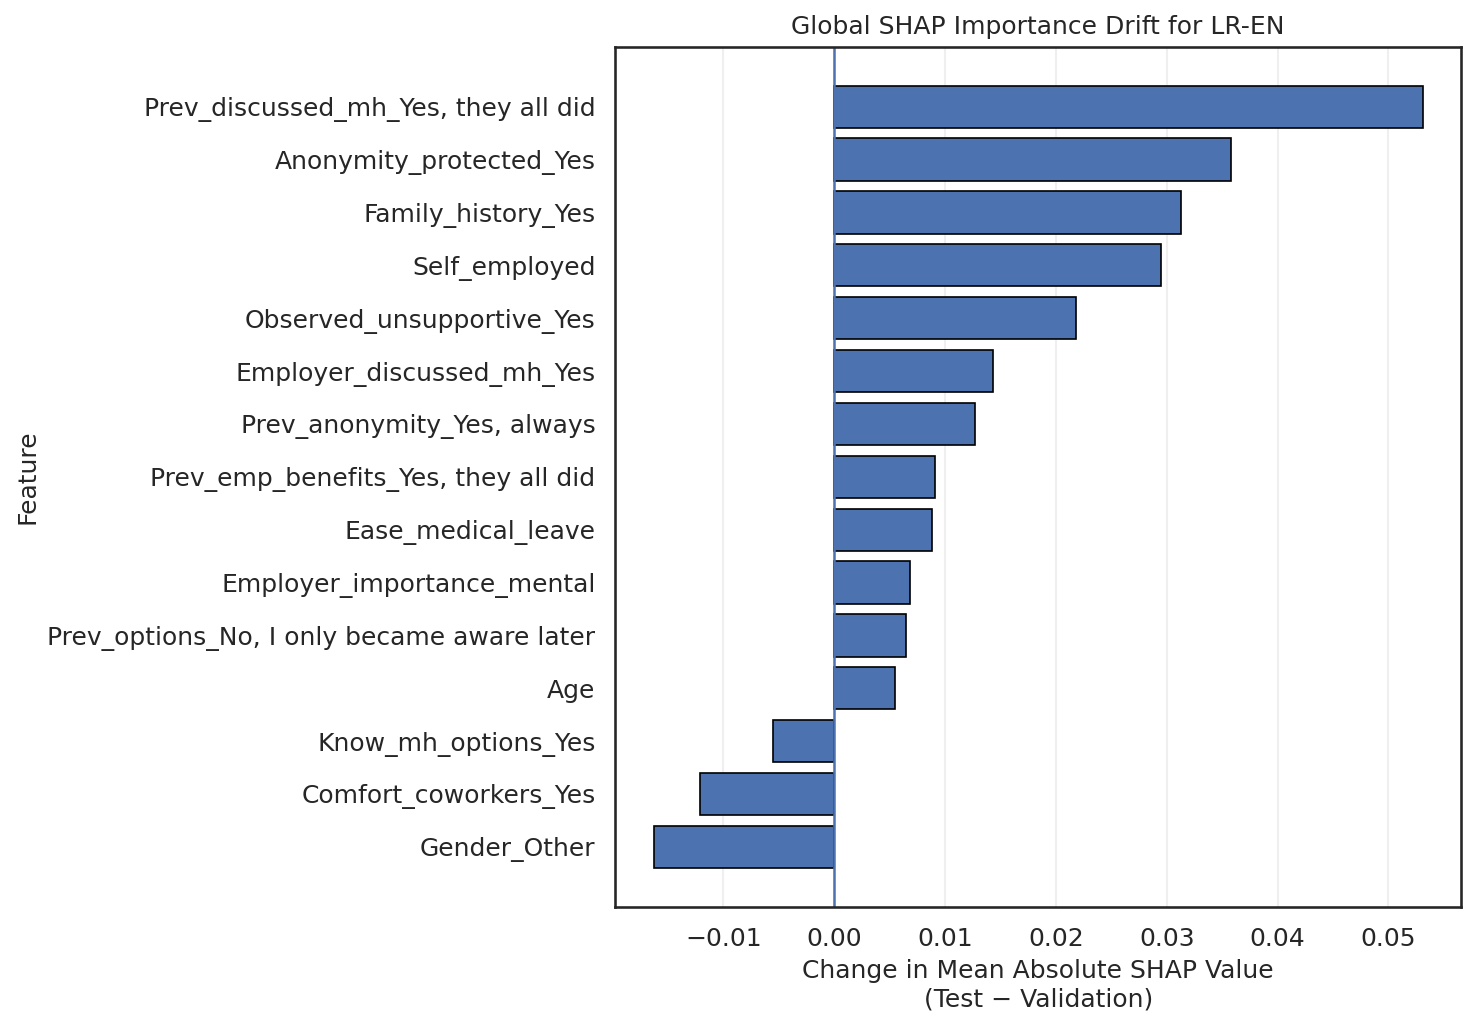

In [64]:
# ============================================================
# Global SHAP Importance Drift Plot
# ============================================================

top_n = 15

plot_df = (
    shap_drift_df
    .head(top_n)
    .sort_values(
        "SHAP Importance Change",
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    plot_df["Feature"],
    plot_df["SHAP Importance Change"],
    edgecolor="black",
    linewidth=0.8
)

ax.axvline(
    x=0,
    linewidth=1.2
)

ax.set_xlabel(
    "Change in Mean Absolute SHAP Value\n"
    "(Test − Validation)"
)

ax.set_ylabel("Feature")

ax.set_title(
    "Global SHAP Importance Drift for LR-EN"
)

ax.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()

base_name = "lr_en_global_shap_importance_drift"

png_path = os.path.join(
    out_dir,
    f"{base_name}.png"
)

pdf_path = os.path.join(
    out_dir,
    f"{base_name}.pdf"
)

plt.savefig(
    png_path,
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.savefig(
    pdf_path,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()
plt.close(fig)

The interpretation should be:

SHAP driftj​=∣ϕj​∣​test​−∣ϕj​∣​validation​

validation
	​
Therefore:

positive values indicate that a feature contributed more strongly to model predictions in the post-shift cohort;
negative values indicate reduced contribution;
values close to zero indicate relatively stable global importance.

In [66]:
print("Top 10 features whose importance decreased post-shift:")
print(shap_drift_df.sort_values('SHAP Importance Change', ascending=True).head(20).to_markdown(index=False, floatfmt=".4f"))

Top 10 features whose importance decreased post-shift:
| Feature                                      |   Mean |SHAP| Validation |   Mean |SHAP| Test |   SHAP Importance Change |   Absolute SHAP Drift |   Relative Change (%) |
|:---------------------------------------------|-------------------------:|-------------------:|-------------------------:|----------------------:|----------------------:|
| Gender_Other                                 |                   0.0548 |             0.0385 |                  -0.0163 |                0.0163 |              -29.6904 |
| Comfort_coworkers_Yes                        |                   0.1730 |             0.1608 |                  -0.0121 |                0.0121 |               -7.0043 |
| Know_mh_options_Yes                          |                   0.1615 |             0.1559 |                  -0.0056 |                0.0056 |               -3.4372 |
| Mh_benefits_Not Eligible                     |                   0.0218 |          

Top 20 Features by SHAP Importance Drift (Val vs Test)


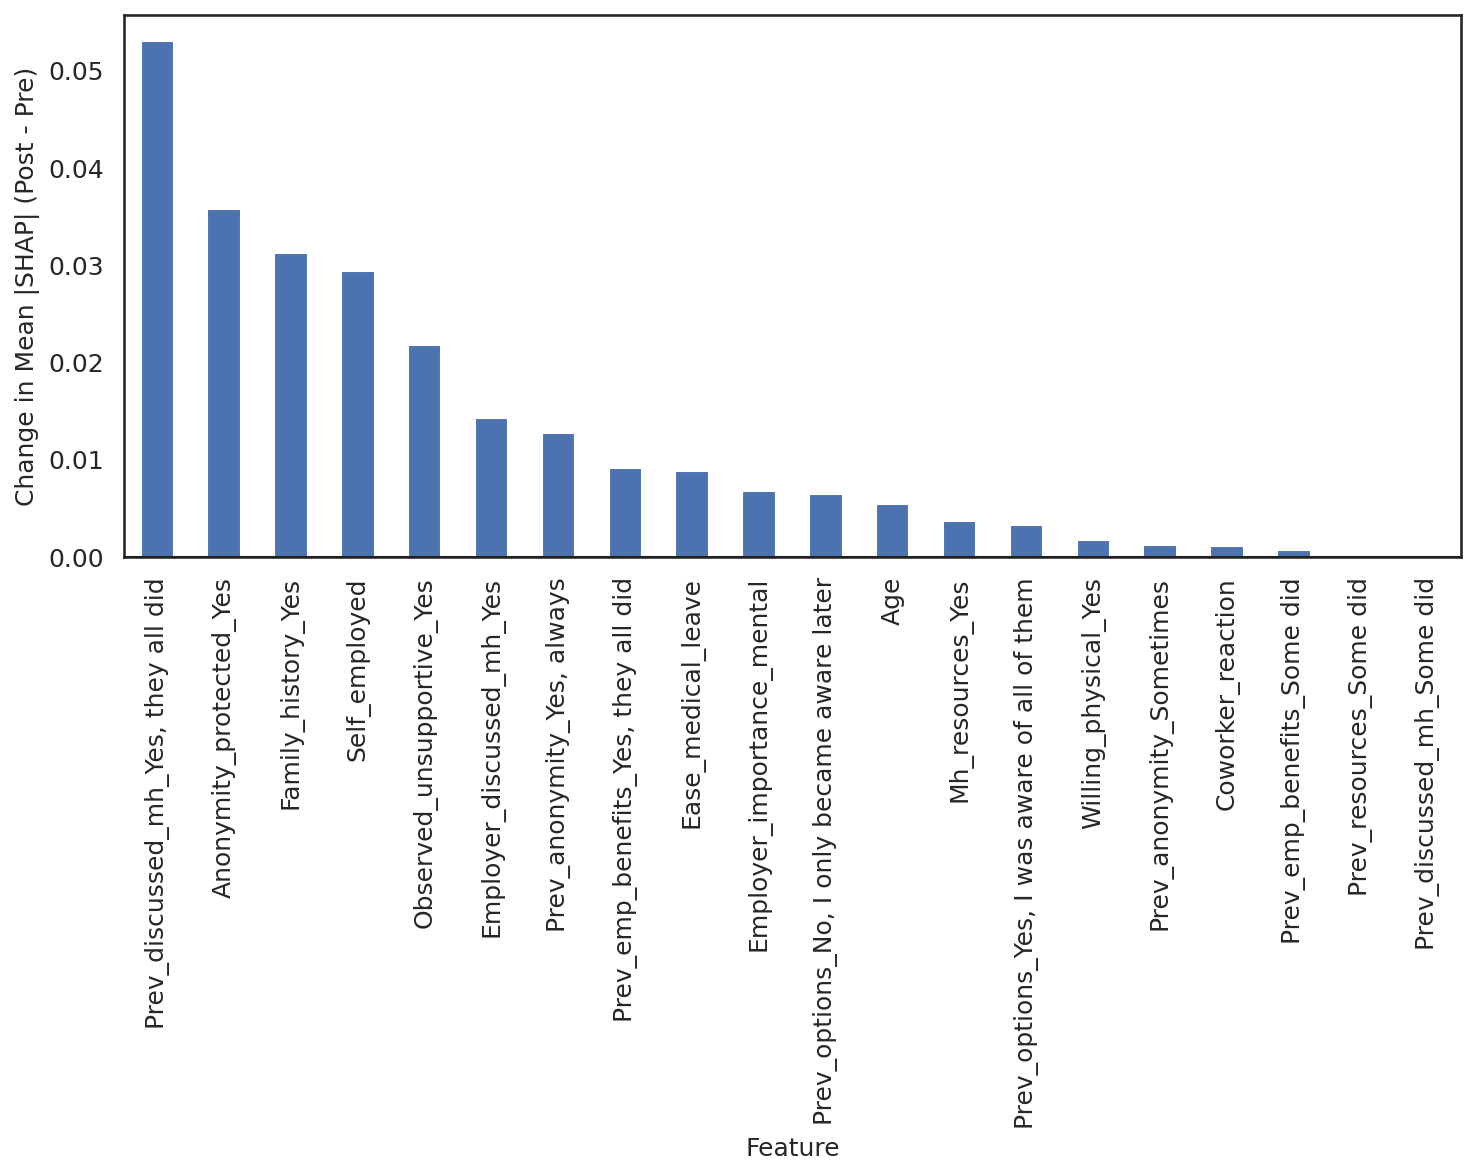

In [68]:
# SHAP drift barplot
plt.figure(figsize=(10, 8))
shap_drift_df.set_index('Feature')['SHAP Importance Change'].sort_values(ascending=False).head(20).plot(kind='bar')
plt.axhline(0, color='black', linewidth=1)
plt.ylabel('Change in Mean |SHAP| (Post - Pre)')
print('Top 20 Features by SHAP Importance Drift (Val vs Test)')
plt.tight_layout()
plt.show()

#### **Pre-shift**

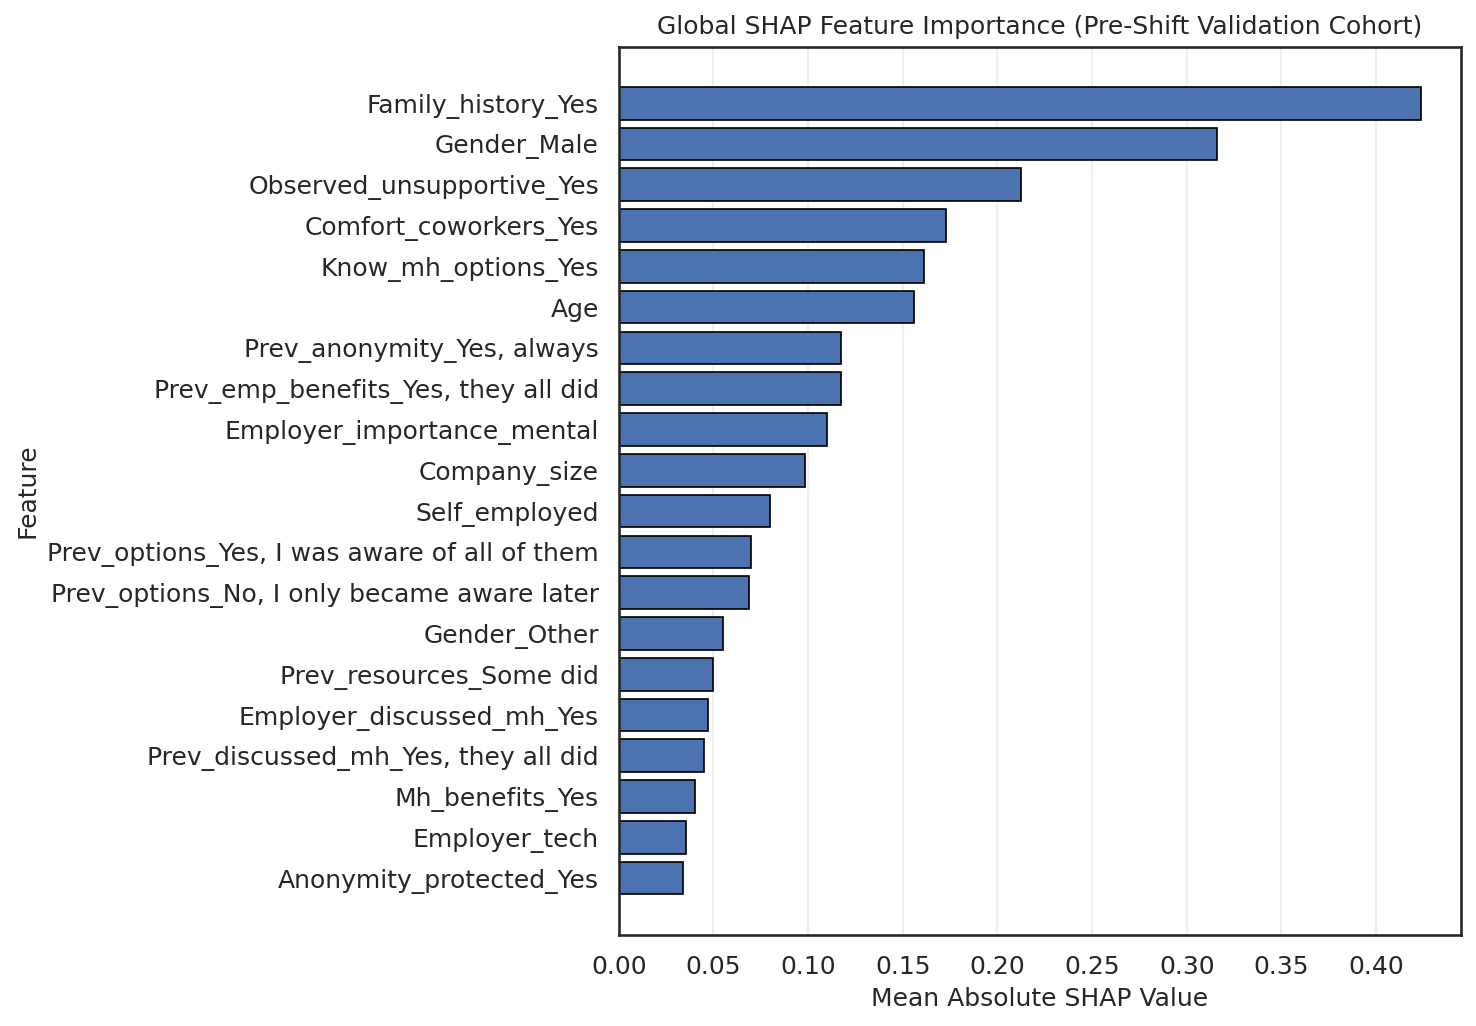

In [78]:
# ============================================================
# Global SHAP Feature Importance (Pre-Shift)
# ============================================================

TOP_N = 20

# Mean absolute SHAP values (already computed)
global_shap_val_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean |SHAP|": mean_abs_shap_val
})

global_shap_val_df = (
    global_shap_val_df
    .sort_values(
        "Mean |SHAP|",
        ascending=False
    )
    .head(TOP_N)
    .sort_values(
        "Mean |SHAP|",
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    global_shap_val_df["Feature"],
    global_shap_val_df["Mean |SHAP|"],
    edgecolor="black",
    linewidth=0.8
)

ax.set_xlabel("Mean Absolute SHAP Value")
ax.set_ylabel("Feature")

ax.set_title(
    "Global SHAP Feature Importance (Pre-Shift Validation Cohort)"
)

ax.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()

# Save
base_name = "lr_en_global_shap_pre_shift"

png_path = os.path.join(
    out_dir,
    f"{base_name}.png"
)

pdf_path = os.path.join(
    out_dir,
    f"{base_name}.pdf"
)

plt.savefig(
    png_path,
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.savefig(
    pdf_path,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()
plt.close(fig)

#### **Post-Shift**

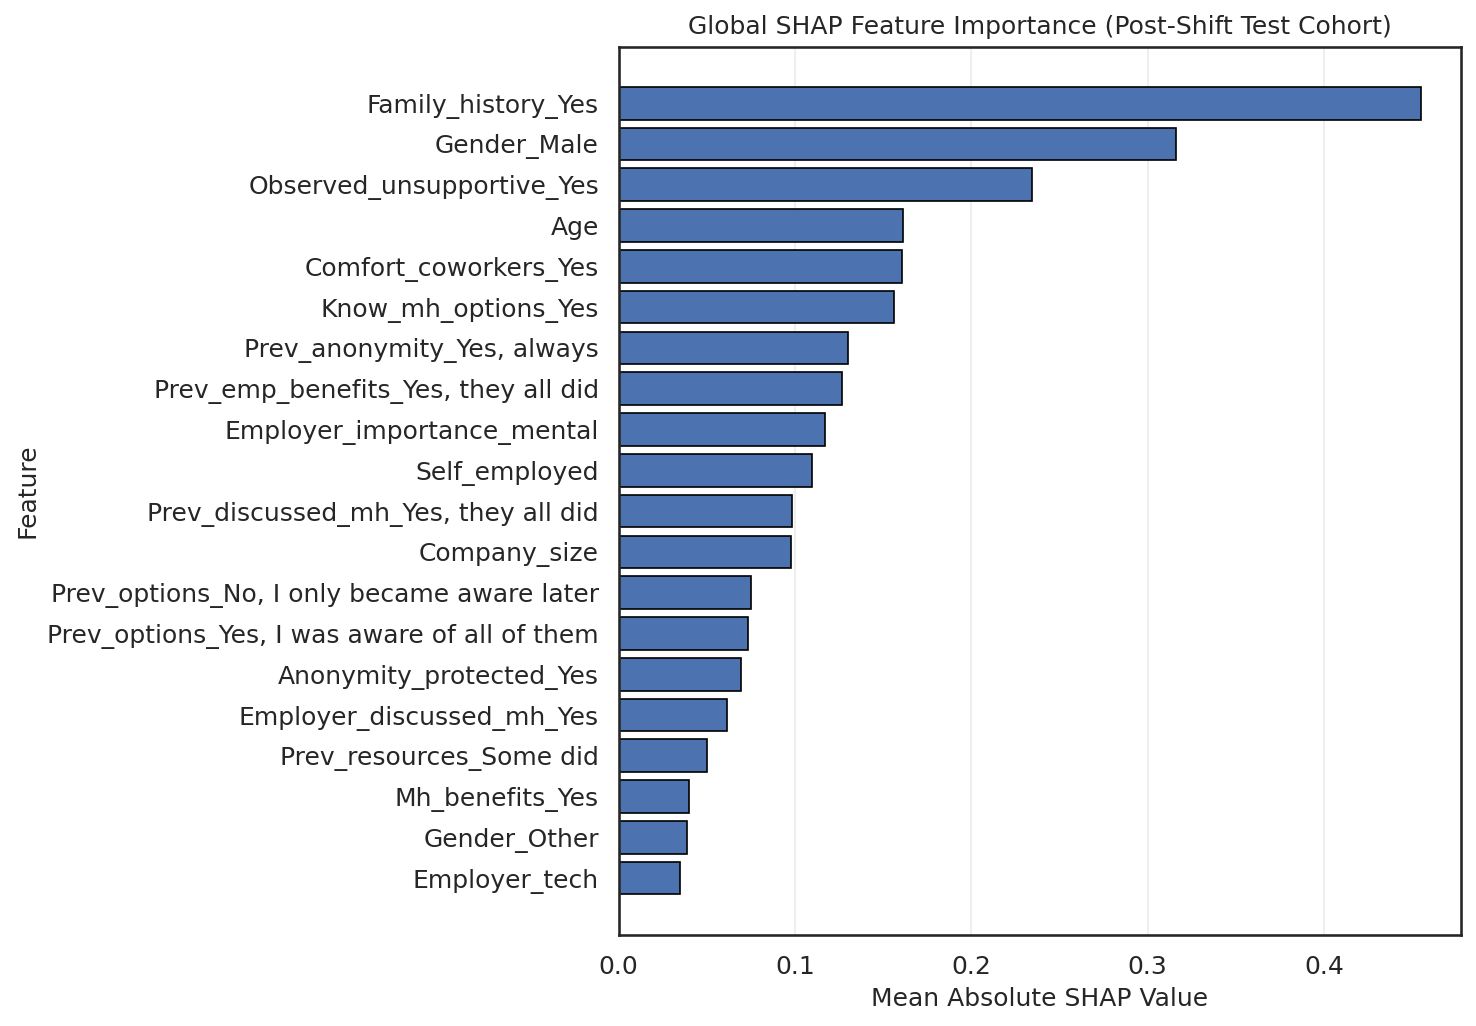

In [79]:
# ============================================================
# Global SHAP Feature Importance (Post-Shift)
# ============================================================

TOP_N = 20

# Mean absolute SHAP values for the post-shift test cohort
global_shap_test_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean |SHAP|": mean_abs_shap_test
})

global_shap_test_df = (
    global_shap_test_df
    .sort_values(
        "Mean |SHAP|",
        ascending=False
    )
    .head(TOP_N)
    .sort_values(
        "Mean |SHAP|",
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    global_shap_test_df["Feature"],
    global_shap_test_df["Mean |SHAP|"],
    edgecolor="black",
    linewidth=0.8
)

ax.set_xlabel("Mean Absolute SHAP Value")
ax.set_ylabel("Feature")

ax.set_title(
    "Global SHAP Feature Importance (Post-Shift Test Cohort)"
)

ax.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()

# Save
base_name = "lr_en_global_shap_post_shift"

png_path = os.path.join(
    out_dir,
    f"{base_name}.png"
)

pdf_path = os.path.join(
    out_dir,
    f"{base_name}.pdf"
)

plt.savefig(
    png_path,
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.savefig(
    pdf_path,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()
plt.close(fig)